# Проект «Маркетинг»

## Исходные данные по проекту и импорт библиотек.

### Цели и задачи проекта.

Интернет-магазин собирает историю покупателей, проводит рассылки предложений и планирует будущие продажи. Для оптимизации процессов надо выделить пользователей, которые готовы совершить покупку в ближайшее время.

**Цель проекта**: \
Предсказать вероятность покупки в течение 90 дней.

**Задачи**:
- Изучить данные
- Разработать полезные признаки
- Создать модель для классификации пользователей
- Улучшить модель и максимизировать метрику roc_auc
- Выполнить тестирование

Для решения поставленных задач потребуется провести следующие этапы работ:
1. Изучим полученные исходные данные. Определим их полноту и корректность формата.
2. Проведем предобработку данных - проверим исходные данные на наличие пропусков и дубликатов.
3. Объединим датасеты в единую таблицу для решения задачи. Разработаем новые признаки, полезные для работы модели.
4. Проведем исследовательский и корреляционный анализы признаков датасетов.
5. Подготовим датасет для обучения модели предсказания вероятности покупки.
6. Обучим несколько моделей и выберем лучшую при помощи кросс-валидации. Метрика качества - ROC_AUC.
7. Протестируем модель, сделав предсказание на тестовой выборке. Проведем оценку признаков.
8. Проведем анализ полученных результатов, подготовим вывод исследования и рекомендации по проекту.

### Описание исходных данных.

Датасет **apparel-purchases.csv** - данные о покупках клиентов по дням и по товарам. В каждой записи покупка определенного товара, его цена, количество штук. \
Признаки:
- client_id - идентификатор пользователя
- quantity - количество товаров в заказе
- price - цена товара
- category_ids - вложенные категории, к которым отнсится товар
- date - дата покупки
- message_id - идентификатор сообщения из рассылки

Датасет **apparel-messages.csv** - данные о рассылках, которые были отправлены клиентам из таблицы покупок. \
Признаки:
- bulk_campaign_id - идентификатор рекламной кампании
- client_id - идентификатор пользователя
- message_id - идентификатор сообщений
- event - тип действия
- channel - канал рассылки
- date - дата рассылки
- created_at - точное время создания сообщения

Датасет **apparel-target_binary.csv** - данные о целевом признаке (совершит ли клиент покупку в течение следующих 90 дней). \
Признаки:
- client_id - идентификатор пользователя
- target - целевой признак.

### Импорт необходимых библиотек.

In [456]:
!pip install -q phik
!pip install -U scikit-learn -q
!pip install -q shap
!pip install -q gdown
!pip install -q lightgbm

In [457]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import phik
import shap
import warnings
import requests
import gdown
import ast
import lightgbm as lgb

from phik.report import plot_correlation_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from io import BytesIO
# импортируем необходимые для проекта библиотеки

pd.set_option('max_rows', None)
pd.set_option('max_columns', None)
pd.set_option('display.max_colwidth', None)
warnings.filterwarnings('ignore')
# настраиваем вывод таблиц в полном объеме и скрываем предупреждения.

In [458]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
# определяем RANDOM_STATE и TEST_SIZE для обучения моделей

### Загрузка датасетов.

In [459]:
purchases_id = '1YHOXS69YdO7d1QH7mRujwd16_gbR-JJFWKmeX1nwvOk'
purchases_file = 'https://docs.google.com/spreadsheets/d/{}/export?format=csv'.format(purchases_id)
r = requests.get(purchases_file)
purchases_data = pd.read_csv(BytesIO(r.content))
purchases_data.head()
# загружаем датасет с данными о покупках и смотрим первые 5 строк

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [460]:
messages_id = "10t6KtJEacv1Sw7b_jXTpsF3mOOTe_65l"
messages_file = f"https://drive.google.com/uc?id={messages_id}"
output = "apparel-messages.csv"  # Имя файла для сохранения
gdown.download(messages_file, output, quiet=False)
messages_data = pd.read_csv("apparel-messages.csv")
messages_data.head()
# загружаем датасет с данными о рассылках и смотрим первые 5 строк

Downloading...
From (original): https://drive.google.com/uc?id=10t6KtJEacv1Sw7b_jXTpsF3mOOTe_65l
From (redirected): https://drive.google.com/uc?id=10t6KtJEacv1Sw7b_jXTpsF3mOOTe_65l&confirm=t&uuid=00e03c7e-bf37-4988-a80d-10ecbb0a32d8
To: C:\Users\evgen\Projects\apparel-messages.csv
100%|█████████████████████████████████████████████████████████████████████████████| 1.41G/1.41G [00:58<00:00, 24.4MB/s]


,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [461]:
target_id = '16VyF4qbTHI8FFB4rii_wJhAe79mekbSAEkADZavdd24'
target_file = 'https://docs.google.com/spreadsheets/d/{}/export?format=csv'.format(target_id)
r = requests.get(target_file)
target_data = pd.read_csv(BytesIO(r.content))
target_data.head()
# загружаем датасет с данными о целевом признаке и смотрим первые 5 строк

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


### Изучение общей информации о данных.

In [462]:
purchases_data.info()
# смотрим общую информацию по датасету с покупками

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  object 
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.3+ MB


In [463]:
purchases_data.describe()
# смотрим основные числовые характеристики датасета с покупками

,quantity,price
count,202208.000000,202208.000000
mean,1.006483,1193.301516
std,0.184384,1342.252664
min,1.000000,1.000000
25%,1.000000,352.000000
50%,1.000000,987.000000
75%,1.000000,1699.000000
max,30.000000,85499.000000


In [464]:
messages_data.info()
# смотрим общую информацию по датасету с рассылками

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   bulk_campaign_id  int64 
 1   client_id         int64 
 2   message_id        object
 3   event             object
 4   channel           object
 5   date              object
 6   created_at        object
dtypes: int64(2), object(5)
memory usage: 680.4+ MB


In [465]:
target_data.info()
# смотрим общую информацию по датасету с таргетом

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  49849 non-null  object
 1   target     49849 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 779.0+ KB


### Вывод по предварительному анализу данных.

Мы загрузили три датасета: с данными о покупках (это основной датасет для анализа) - purchases_data, данными о рекламных рассылках - messages_data, и данные с целевым признаком для предсказания (target - факт покупки через 90 дней) - target_data.

В датасете **purchases_data** 202 208 строк с данными. Пропусков нет, все признаки имеют верный тип кроме date. Он имеет формат строки, хотя содержит дату. Анализ числовых показателей показывает наличие странных аномалий:
- признак quantity имеет максимальное значение 30, хотя 75% данных имеет значение 1;
- минимальное значение цены товара price = 1.

В датасете **messages_data** 12 739 798 строк с данными. Все признаки имеют верный тип кроме date и created_at. Они имеют формат строки, хотя содержат дату. Анализ числовых показателей не проводим, поскольку в данном датасете числовой формат имеют только признаки id.

В датасете **target_data** 49 849 строк с данными. Пропусков нет, все признаки имеют верный тип. Анализ числовых показателей не проводим, поскольку в данном датасете числовой формат имеет только целевой признак (1 и 0).

## Предобработка данных.

In [466]:
purchases_data_temp = purchases_data.copy()
messages_data_temp = messages_data.copy()
target_data_temp = target_data.copy()
print(len(purchases_data_temp))
print(len(messages_data_temp))
print(len(target_data_temp))
# создаем копию датасетов до преобразования и фиксируем, сколько строк было изначально.

202208
12739798
49849


### Изменение типов данных.

In [467]:
purchases_data['date'] = pd.to_datetime(purchases_data['date'], format='%Y-%m-%d')
messages_data['date'] = pd.to_datetime(messages_data['date'], format='%Y-%m-%dT%H:%M:%S')
messages_data['created_at'] = pd.to_datetime(messages_data['created_at'], format='%Y-%m-%dT%H:%M:%S')
# Переводим даты из формата строки (object) в формат даты (datetime)

print(purchases_data.info())
print(messages_data.info())
# смотрим, что получилось

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     202208 non-null  object        
 1   quantity      202208 non-null  int64         
 2   price         202208 non-null  float64       
 3   category_ids  202208 non-null  object        
 4   date          202208 non-null  datetime64[ns]
 5   message_id    202208 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 9.3+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bulk_campaign_id  int64         
 1   client_id         int64         
 2   message_id        object        
 3   event             object        
 4   channel           object        
 5   date       

### Анализ пропусков.

На этапе предварительного просмотра мы не выявили пропусков, но проведем дополнительный анализ.

In [468]:
def check_nan(data):
    """Эта функция считает количество пропусков в датасете и выводит соответствующее сообщение.

    В качестве аргумента передается название датасета. Функция по всем столбцам проведет подсчет пропусков и выведет
    их количество в сообщении. Если они есть, выводятся также названия столбцов с пропуском и их процент в данных"""
    nan_sum = 0
    for i in data:
        nan_sum += data[i].isna().sum()
    if nan_sum == 0:
        return print(f'Пропусков в датасете не обнаружено.')
    else:
        print(f'Обнаружены пропуски в датасете в количестве {nan_sum}. Требуется изучить данные подробнее.')
        nan_columns = []
        for j in data:
            if data[j].isna().sum() > 0:
                nan_columns.append(j)
        print(f'Обнаружены пропуски в столбцах {nan_columns}.')
        columns = data.columns
        for column in columns:
            check_col = data[column].isna().sum()
            perc_nul = data[column].isna().sum() / len(autos_data)
            print(column, check_col, f'{perc_nul:.2%}')
# Пишем функцию подсчета и проверки пропусков в датафрейме

In [469]:
dataframes = {
    'purchases_data': purchases_data,
    'messages_data': messages_data,
    'target_data': target_data
}
# создаем словарь с названиями датафреймов
for name, df in dataframes.items():
    print(f'Датасет {name}:')
    display(check_nan(df))
# Применяем функции ко всем датасетам

Датасет purchases_data:
Пропусков в датасете не обнаружено.


None

Датасет messages_data:
Пропусков в датасете не обнаружено.


None

Датасет target_data:
Пропусков в датасете не обнаружено.


None

### Анализ дубликатов.

#### Анализ явных дубликатов.

In [470]:
for name, df in dataframes.items():
    print(f'Явных дубликатов в датасете {name}:', df.duplicated().sum())
# считаем явные дубликаты в датасетах

Явных дубликатов в датасете purchases_data: 73020
Явных дубликатов в датасете messages_data: 48610
Явных дубликатов в датасете target_data: 5


In [471]:
purchases_data = purchases_data.drop_duplicates(keep='first').reset_index(drop=True)
messages_data = messages_data.drop_duplicates(keep='first').reset_index(drop=True)
target_data = target_data.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Явных дубликатов в датасете purchases_data:', purchases_data.duplicated().sum())
print(f'Явных дубликатов в датасете messages_data:', messages_data.duplicated().sum())
print(f'Явных дубликатов в датасете target_data:', target_data.duplicated().sum())
# удаляем полные дубликаты строк и сбрасываем индексы

Явных дубликатов в датасете purchases_data: 0
Явных дубликатов в датасете messages_data: 0
Явных дубликатов в датасете target_data: 0


#### Анализ неявных дубликатов.

Большая часть данных в датасетах - идентификаторы, которые не требуют проверки на неявные дубликаты. Но в датасете messages_data есть несколько признаков, которые следует проверить - event и channel.

In [472]:
messages_data['event'].sort_values().unique()
# смотрим уникальные значения в признаке event

array(['click', 'close', 'complain', 'hard_bounce', 'hbq_spam', 'open',
       'purchase', 'send', 'soft_bounce', 'subscribe', 'unsubscribe'],
      dtype=object)

In [473]:
messages_data['channel'].sort_values().unique()
# смотрим уникальные значения в признаке channel

array(['email', 'mobile_push'], dtype=object)

Неявных дубликатов не выявлено.

### Выводы по предобработке.

In [474]:
print('Количество записей в purchases_data после обработки', len(purchases_data))
print('Количество записей до обработки датасета purchases_data:', len(purchases_data_temp))
print(f'Процент потерь: {(1 - (len(purchases_data) / len(purchases_data_temp))):.2%}')
print('Количество записей в messages_data после обработки', len(messages_data))
print('Количество записей до обработки датасета messages_data:', len(messages_data_temp))
print(f'Процент потерь: {(1 - (len(messages_data) / len(messages_data_temp))):.2%}')
print('Количество записей в target_data после обработки', len(target_data))
print('Количество записей до обработки датасета target_data:', len(target_data_temp))
print(f'Процент потерь: {(1 - (len(target_data) / len(target_data_temp))):.2%}')
# смотрим % потерь

Количество записей в purchases_data после обработки 129188
Количество записей до обработки датасета purchases_data: 202208
Процент потерь: 36.11%
Количество записей в messages_data после обработки 12691188
Количество записей до обработки датасета messages_data: 12739798
Процент потерь: 0.38%
Количество записей в target_data после обработки 49844
Количество записей до обработки датасета target_data: 49849
Процент потерь: 0.01%


На данном этапе исследования мы изменили столбцы с некорректным типом данных (date и created_at). Мы привели их к формату даты. Затем мы сделали дополнительную проверку пропусков и подтвердили их отсутствие в данных. На последнем шаге этапа мы проверили данные на дубликаты. Было выявлено:
- Явных дубликатов в датасете purchases_data: 73020
- Явных дубликатов в датасете messages_data: 48610
- Явных дубликатов в датасете target_data: 5

Мы удалили дубли в данных. Неявных дубликатов не выявлено.

## Объединение таблиц и создание новых признаков.

Целевым признаком является вероятность покупки в следующие 90 дней конкретным покупателем. Таким образом, мы оцениваем по признакам конкретных покупателей. Для подготовки данных для модели нам нужно привести данные о покупках и рассылках к характеристикам конкретных пользователей.

### Объединение purchases_data и messages_data.

In [475]:
messages_data = messages_data.rename(columns={'client_id': 'client_id_mes', 'date': 'date_mes'})
# переименовываем столбцы, совпадающие по названию в двух датасетах

In [476]:
messages_data.query('message_id == "1515915625491869271-2090-61a72488d6a0f"')
# смотрим пример по одному идентификатору сообщения

,bulk_campaign_id,client_id_mes,message_id,event,channel,date_mes,created_at
4675172,2090,1515915625491869271,1515915625491869271-2090-61a72488d6a0f,click,email,2023-04-12,2023-04-12 08:25:33
4806634,2090,1515915625491869271,1515915625491869271-2090-61a72488d6a0f,click,email,2023-04-18,2023-04-18 11:47:45
5683129,2090,1515915625491869271,1515915625491869271-2090-61a72488d6a0f,click,email,2023-06-13,2023-06-13 11:10:41
10934598,2090,1515915625491869271,1515915625491869271-2090-61a72488d6a0f,click,email,2023-12-28,2023-12-28 11:25:50


В данных по рассылкам очень много сообщений были отправлены несколько раз. Для решения задачи вряд ли имеет значение время отправки. Уберем этот столбец. А данные по дате преобразуем: оставим в date_mes самую последнюю дату, а также добавим параметр - количество отправок mes_qty, в котором сагрегируем все имеющиеся даты отправки.

In [477]:
messages_data['mes_qty'] = messages_data.groupby('message_id')['date_mes'].transform('nunique')
# добавляем столбец с количеством отправок

In [478]:
messages_data = messages_data.sort_values('date_mes', ascending=False)
# сортируем таблицу по дате date_mes
messages_data = messages_data.drop('created_at', axis=1)
# убираем ненужный столбец со временем создания

In [479]:
messages_data = messages_data.drop_duplicates(subset=['message_id'], keep='first')
# удаляем дубли по id рассылки, оставив только записи с последней датой отправки

In [480]:
messages_data.duplicated().sum()
# проверяем на дубли

0

In [481]:
messages_data.shape
# смотрим, сколько записей осталось в датасете

(9061667, 7)

In [482]:
purchases_mes = purchases_data.join(messages_data.set_index('message_id'), on='message_id', how='inner')
# объединяем purchases_data и messages_data.
purchases_mes.head()
# смотрим, что получилось

,client_id,quantity,price,category_ids,date,message_id,bulk_campaign_id,client_id_mes,event,channel,date_mes,mes_qty
7,1515915625490739153,1,1999.0,"['2', '18', '123', '451']",2022-05-16,1515915625490739153-4172-626b943cc789b,4172,1515915625490739153,open,email,2022-05-27,1
11,1515915625491869271,2,599.0,"['4', '27', '350', '1392']",2022-05-16,1515915625491869271-2090-61a72488d6a0f,2090,1515915625491869271,click,email,2023-12-28,4
19,1515915625566606509,1,349.0,"['5562', '5634', '5579', '710']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1
20,1515915625566606509,1,299.0,"['5562', '5634', '5579', '710']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1
21,1515915625566606509,1,999.0,"['5562', '5634', '5568', '957']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1


In [483]:
purchases_mes.shape
# смотрим на размер получившейся таблицы

(128502, 12)

### Объединение purchases_data и target_data.

В данных о покупках у одного покупателя может быть несколько заказов. Поэтому нам нужно свести данные о покупках к агрегируемым параметрам. Добавим в качестве признака покупателя сумму всех заказов, средний чек (оба параметра высчитаем на основании price), добавим параметр со средним количеством категорий покупок (на основании category_ids), средним и общим количеством заказов (на основании quantity) и оставим только дату последнего заказа (на основании date).

In [484]:
purchases_mes.query('client_id == "1515915625566606509"')
# смотрим пример по одному идентификатору пользователя

,client_id,quantity,price,category_ids,date,message_id,bulk_campaign_id,client_id_mes,event,channel,date_mes,mes_qty
19,1515915625566606509,1,349.0,"['5562', '5634', '5579', '710']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1
20,1515915625566606509,1,299.0,"['5562', '5634', '5579', '710']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1
21,1515915625566606509,1,999.0,"['5562', '5634', '5568', '957']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1
22,1515915625566606509,1,399.0,"['5562', '5634', '5693', '636']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1


In [485]:
purchases_mes['price_sum'] = purchases_mes.groupby('client_id')['price'].transform('sum')
purchases_mes['price_max'] = purchases_mes.groupby('client_id')['price'].transform('max')
purchases_mes['price_min'] = purchases_mes.groupby('client_id')['price'].transform('min')
purchases_mes['price_avg'] = purchases_mes.groupby('client_id')['price'].transform('mean')
purchases_mes['price_avg'] = purchases_mes['price_avg'].round(2)
# добавляем столбец с суммой заказа и со средним чеком

In [486]:
def category_count(column):
    """Эта функция считает количество значений в поле, которое содержит в себе список значений.

    В качестве аргумента передается название колонки. Функция преобразует строку в список и считает количество значений в списке. 
    Возвращает это значение"""
    count = len(ast.literal_eval(column))
    return count
# пишем функцию для подсчета значений в поле со списком категорий покупок

In [487]:
purchases_mes['category_ids_qty'] = purchases_mes['category_ids'].apply(category_count)
# применяем функцию и создаем новый столбец с количеством категорий

In [488]:
purchases_mes['qty_sum'] = purchases_mes.groupby('client_id')['quantity'].transform('sum')
purchases_mes['qty_avg'] = purchases_mes.groupby('client_id')['quantity'].transform('mean')
purchases_mes['qty_avg'] = purchases_mes['qty_avg'].round(2)
# добавляем столбец с общим количеством и средним количеством

In [489]:
purchases_mes.head()

,client_id,quantity,price,category_ids,date,message_id,bulk_campaign_id,client_id_mes,event,channel,date_mes,mes_qty,price_sum,price_max,price_min,price_avg,category_ids_qty,qty_sum,qty_avg
7,1515915625490739153,1,1999.0,"['2', '18', '123', '451']",2022-05-16,1515915625490739153-4172-626b943cc789b,4172,1515915625490739153,open,email,2022-05-27,1,1999.0,1999.0,1999.0,1999.0,4,1,1.0
11,1515915625491869271,2,599.0,"['4', '27', '350', '1392']",2022-05-16,1515915625491869271-2090-61a72488d6a0f,2090,1515915625491869271,click,email,2023-12-28,4,599.0,599.0,599.0,599.0,4,2,2.0
19,1515915625566606509,1,349.0,"['5562', '5634', '5579', '710']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1,2046.0,999.0,299.0,511.5,4,4,1.0
20,1515915625566606509,1,299.0,"['5562', '5634', '5579', '710']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1,2046.0,999.0,299.0,511.5,4,4,1.0
21,1515915625566606509,1,999.0,"['5562', '5634', '5568', '957']",2022-05-16,1515915625566606509-4301-627b66245401d,4301,1515915625566606509,open,email,2022-06-01,1,2046.0,999.0,299.0,511.5,4,4,1.0


In [490]:
purchases_mes = purchases_mes.sort_values('date', ascending=False)
# сортируем таблицу по дате покупки

In [491]:
purchases_mes = purchases_mes.drop_duplicates(subset=['client_id'], keep='first')
# удаляем дубли по id покупателя, оставив только записи с последней датой покупки
purchases_mes.duplicated().sum()
# проверяем на дубли

0

In [492]:
purchases_mes = purchases_mes.drop(['quantity', 'price', 'category_ids', 'client_id_mes', 'message_id', 'bulk_campaign_id'], axis=1)
# убираем лишние столбцы
purchases_mes['client_id'].duplicated().sum()
# проверяем на дубли по пользователю

0

In [493]:
purchases_mes = purchases_mes.rename(columns={'date': 'last_purchase_date', 'date_mes': 'last_date_mes'})
# переименовываем столбцы, совпадающие по названию в двух датасетах

In [494]:
final_data = target_data.join(purchases_mes.set_index('client_id'), on='client_id', how='left')
# объединяем purchases_mes и target_data.
final_data.head()
# смотрим, что получилось

,client_id,target,last_purchase_date,event,channel,last_date_mes,mes_qty,price_sum,price_max,price_min,price_avg,category_ids_qty,qty_sum,qty_avg
0,1515915625468060902,0,2022-05-27,send,email,2022-05-27,1.0,4795.0,1999.0,199.0,959.00,4.0,5.0,1.0
1,1515915625468061003,1,2023-01-04,send,email,2023-01-04,1.0,14135.0,3499.0,1749.0,2355.83,4.0,6.0,1.0
2,1515915625468061099,0,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1515915625468061100,0,2024-02-10,purchase,mobile_push,2024-02-10,2.0,1049.0,1049.0,1049.0,1049.00,4.0,1.0,1.0
4,1515915625468061170,0,2023-06-17,click,email,2023-06-17,2.0,14102.0,2699.0,7.0,1762.75,4.0,8.0,1.0


In [495]:
final_data.isna().sum()
# смотрим на пропуски в получившемся датафрейме

client_id               0
target                  0
last_purchase_date    260
event                 260
channel               260
last_date_mes         260
mes_qty               260
price_sum             260
price_max             260
price_min             260
price_avg             260
category_ids_qty      260
qty_sum               260
qty_avg               260
dtype: int64

In [496]:
final_data.shape
# смотрим, какой размер у получившегося датафрейма

(49844, 14)

In [497]:
print('Количество записей в final_data', len(final_data))
print('Количество записей с пропусками в final_data:',final_data.isna().any(axis=1).sum())
print(f'Процент потерь, если удалить пропуски: {(final_data.isna().any(axis=1).sum() / len(final_data)):.2%}')

Количество записей в final_data 49844
Количество записей с пропусками в final_data: 260
Процент потерь, если удалить пропуски: 0.52%


Мы видим, что после объединения данных во всех датафреймах у нас получилось 260 строк, где есть данные по покупкам и рассылкам, но нет данных по целевому признаку. Если удалить их из датасета, мы потеряем лишь 0.52% данных. Удалим строки с пропусками для модели.

In [498]:
final_data.dropna(inplace=True)
# удаляем строки с пропусками из итогового датасета
final_data.isna().sum()
# проверяем, что получилось по пропускам

client_id             0
target                0
last_purchase_date    0
event                 0
channel               0
last_date_mes         0
mes_qty               0
price_sum             0
price_max             0
price_min             0
price_avg             0
category_ids_qty      0
qty_sum               0
qty_avg               0
dtype: int64

In [499]:
final_data.shape
# еще раз смотрим, какой размер у получившегося датафрейма

(49584, 14)

В полученном датасете осталось два категориальных признака, которые в текущем виде плохо подойдут для модели ввиду большого количества возможных вариантов - last_purchase_date и last_date_mes. Преобразуем их в более крупные категории - год и месяц последней покупки и год и месяц последней рассылки. А также добавим отдельным признаком только годы. После проведения корреляционного анализа выберем тот признак, который подойдет лучше.

In [500]:
final_data['purch_year'] = final_data['last_purchase_date'].dt.year
final_data['mes_year'] = final_data['last_date_mes'].dt.year
# Добавляем в таблицу столбцы с годом последней покупки и годом последней рассылки

In [501]:
final_data['last_purchase_date'] = pd.to_datetime(final_data['last_purchase_date'], format='%Y-%m-%d').dt.strftime('%Y-%m')
final_data['last_date_mes'] = pd.to_datetime(final_data['last_date_mes'], format='%Y-%m-%d').dt.strftime('%Y-%m')
# преобразуем даты последней покупки и рассылки в год-месяц, убрав число

In [502]:
print(final_data['client_id'].duplicated().sum())
print(final_data.duplicated().sum())
# проверяем дубликаты в таблице - полные и по client_id

0
0


In [503]:
final_data = final_data.set_index('client_id')
# сбрасываем индексы в датасете на айди пользователя

In [504]:
final_data.head()
# смотрим, какой получился датасет для обучения

,target,last_purchase_date,event,channel,last_date_mes,mes_qty,price_sum,price_max,price_min,price_avg,category_ids_qty,qty_sum,qty_avg,purch_year,mes_year
client_id,,,,,,,,,,,,,,,
1515915625468060902,0,2022-05,send,email,2022-05,1.0,4795.0,1999.0,199.0,959.00,4.0,5.0,1.0,2022,2022
1515915625468061003,1,2023-01,send,email,2023-01,1.0,14135.0,3499.0,1749.0,2355.83,4.0,6.0,1.0,2023,2023
1515915625468061100,0,2024-02,purchase,mobile_push,2024-02,2.0,1049.0,1049.0,1049.0,1049.00,4.0,1.0,1.0,2024,2024
1515915625468061170,0,2023-06,click,email,2023-06,2.0,14102.0,2699.0,7.0,1762.75,4.0,8.0,1.0,2023,2023
1515915625468061514,0,2022-07,purchase,email,2022-07,2.0,999.0,999.0,999.0,999.00,4.0,1.0,1.0,2022,2022


In [505]:
final_data.info()
# смотрим на характеристики финального датасета

<class 'pandas.core.frame.DataFrame'>
Index: 49584 entries, 1515915625468060902 to 1515915626010266132
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   target              49584 non-null  int64  
 1   last_purchase_date  49584 non-null  object 
 2   event               49584 non-null  object 
 3   channel             49584 non-null  object 
 4   last_date_mes       49584 non-null  object 
 5   mes_qty             49584 non-null  float64
 6   price_sum           49584 non-null  float64
 7   price_max           49584 non-null  float64
 8   price_min           49584 non-null  float64
 9   price_avg           49584 non-null  float64
 10  category_ids_qty    49584 non-null  float64
 11  qty_sum             49584 non-null  float64
 12  qty_avg             49584 non-null  float64
 13  purch_year          49584 non-null  int64  
 14  mes_year            49584 non-null  int64  
dtypes: float64(8), int64(3), o

### Вывод по объединению таблиц.

На данном этапе исследования мы объединили все исходные датасеты в единую таблицу. Для этого мы сначала объединили датасеты purchases_data и messages_data. \
Чтобы не потерять важные признаки, мы создали новые, который агрегирует данные по рассылкам: общее количество отправок mes_qty. Затем мы удалили строки с дублирубщими id рассылок, оставив в date_mes запись с самой последней датой рассылки. После этого мы смогли объединить датасеты по полю message_id. Получившийся датасет мы назвали purchases_mes.\
Далее мы обработали датасет purchases_mes, содержащий данные о покупках и инициирующих их рассылках. Для объединения с датасетом с целевым признаком target_data нужно было свести данные о покупках к характеристикам конкретных покупателей. Поэтому мы создали новые агрегирующие признаки: общее и среднее количество покупок, общую и среднюю сумму заказа, максимальный и минимальный заказ, количество категорий товаров. Затем мы убрали дубли по покупателю, оставив в данных только данные по последней покупке. \
После этого мы смогли объединить датасеты purchases_mes и target_data. В получившемся датасета final_data мы обнаружили 260 пропусков - по целевому признаку нет данных о покупках и рассылках. Пропуски составили всего 0.52%, поэтому мы удалили эти строки из датасета для модели. \
Также мы преобразовали признаки с датами последней покупки и последней рассылки в более крупные: с месяцем и годом, а также отдельно добавили признак год покупки и год рассылки. \
На финальном шаге этапа мы проверили получившийся датасет на пропуски и дубли.

## Исследовательский анализ признаков.

In [506]:
final_data_temp = final_data.copy()
print(len(final_data_temp))
# фиксируем количество записей в датасете перед анализом признаков 

49584


Подготовим функции для анализа количественных и категориальных признаков датасетов.

In [507]:
def kol_an(data, column, hue):
    """Эта функция помогает провести анализ количественных признаков датасета.
    Она выводит основные числовые характеристики столбцов, строит гистрограммы и ящик с усами.

    В качестве аргумента передается название датасета, название анализируемой колонки и количество корзин для гистрограммы. 
    В результате будет выведен числовой анализ, гистрограмма и ящик с усами"""
    print(f'Основные количественные характеристики признака: {column}')
    print(data[column].describe())
    print(f'Графики по признаку: {column}')
    plt.figure(figsize=(15, 8))
    plot = sns.histplot(data=data, x=column, palette='hls', hue=hue)
    plt.xlabel(column)
    plt.ylabel('Кол-во покупателей')
    plt.title(f'Распределение покупателей по признаку: {column}')
    plt.show()
    fig, ax = plt.subplots(figsize = (17,2))
    ax = data[[column]].boxplot(vert = False, ax =ax)
    plt.xlabel(f'{column}')
    ax.set_title(f'Диаграмма размаха значений признака {column}');
    plt.show()
    print('- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -')
# пишем функцию для анализа количественных признаков датасетов

In [508]:
def kat_an(data, column):
    """Эта функция помогает провести анализ категориальных признаков датасета. Она распределяет строки датасета по
    анализируемому параметру, строит столбчатую диаграмму и круговую диаграмму.

    В качестве аргумента передается название датасета и название анализируемой колонки. 
    В результате будет выведено распределение количества строк по колонке, построены столбчатая и круговая диаграмма."""
    kat_group = data[column].value_counts()
    print(f'Распределение покупателей по признаку: {column}')
    print(kat_group)
    kat_name = kat_group.index
    plot = plt.pie(kat_group, labels=kat_name, autopct='%1.2f%%')
    plt.title(f'Диаграммы распределения покупателей по признаку: {column}')
    plt.show()
    fig, ax = plt.subplots(figsize = (17,8))
    ax = kat_group.plot(kind='barh', legend=False)
    plt.xlabel(f'Количество покупателей по признаку: {column}');
    plt.show()
    print('- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -')
# пишем функцию для анализа категориальных признаков

### Анализ количественных признаков.

In [509]:
num_list = final_data.select_dtypes(include=['number']).columns.tolist()
# определяем список количественных признаков датасета final_data
num_list
# смотрим на список количественных признаков

['target',
 'mes_qty',
 'price_sum',
 'price_max',
 'price_min',
 'price_avg',
 'category_ids_qty',
 'qty_sum',
 'qty_avg',
 'purch_year',
 'mes_year']

Основные количественные характеристики признака: target
count    49584.00000
mean         0.01928
std          0.13751
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: target, dtype: float64
Графики по признаку: target


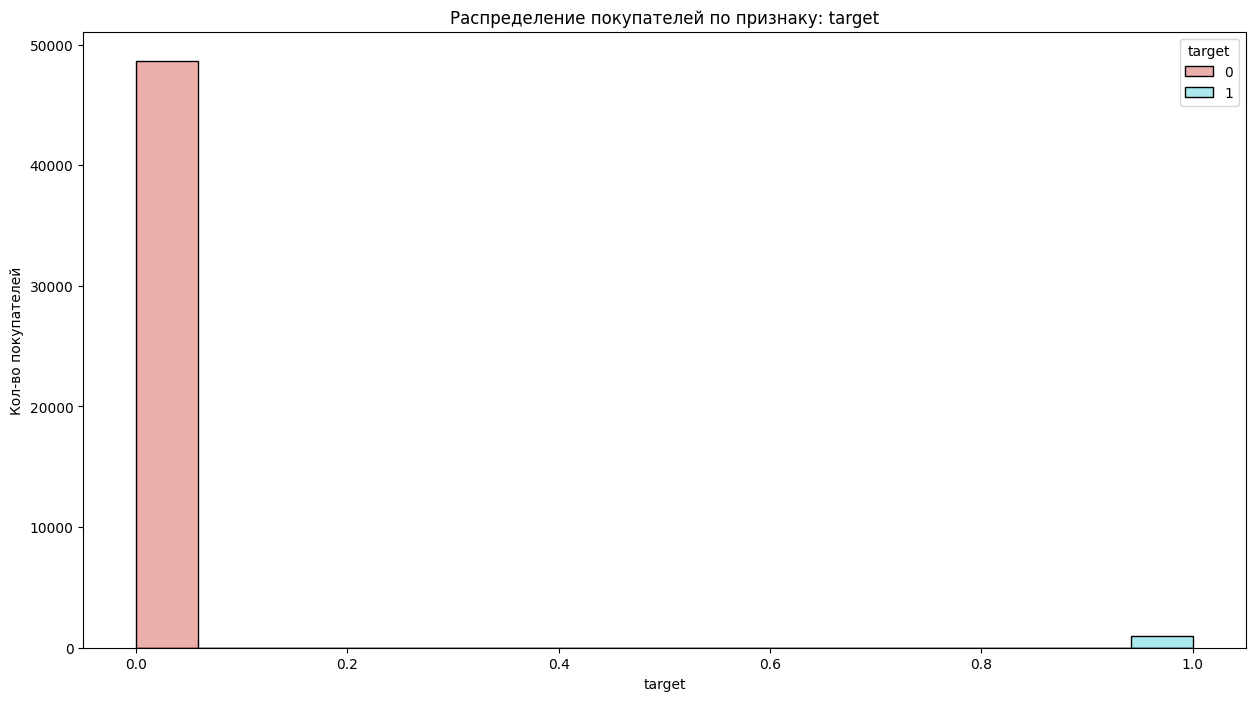

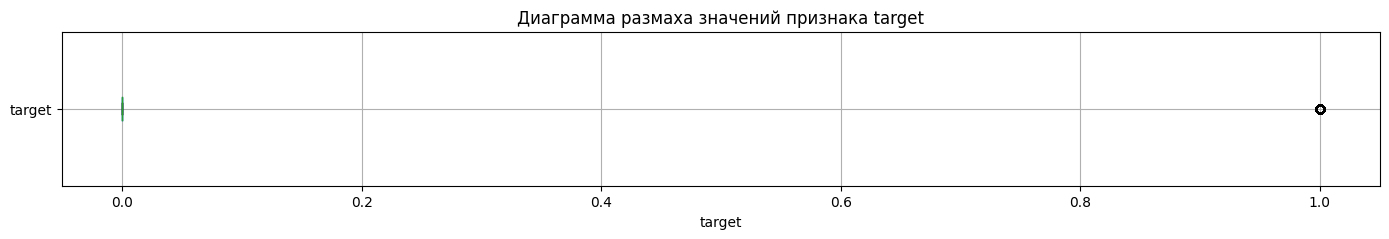

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: mes_qty
count    49584.000000
mean         2.340735
std         13.304199
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        322.000000
Name: mes_qty, dtype: float64
Графики по признаку: mes_qty


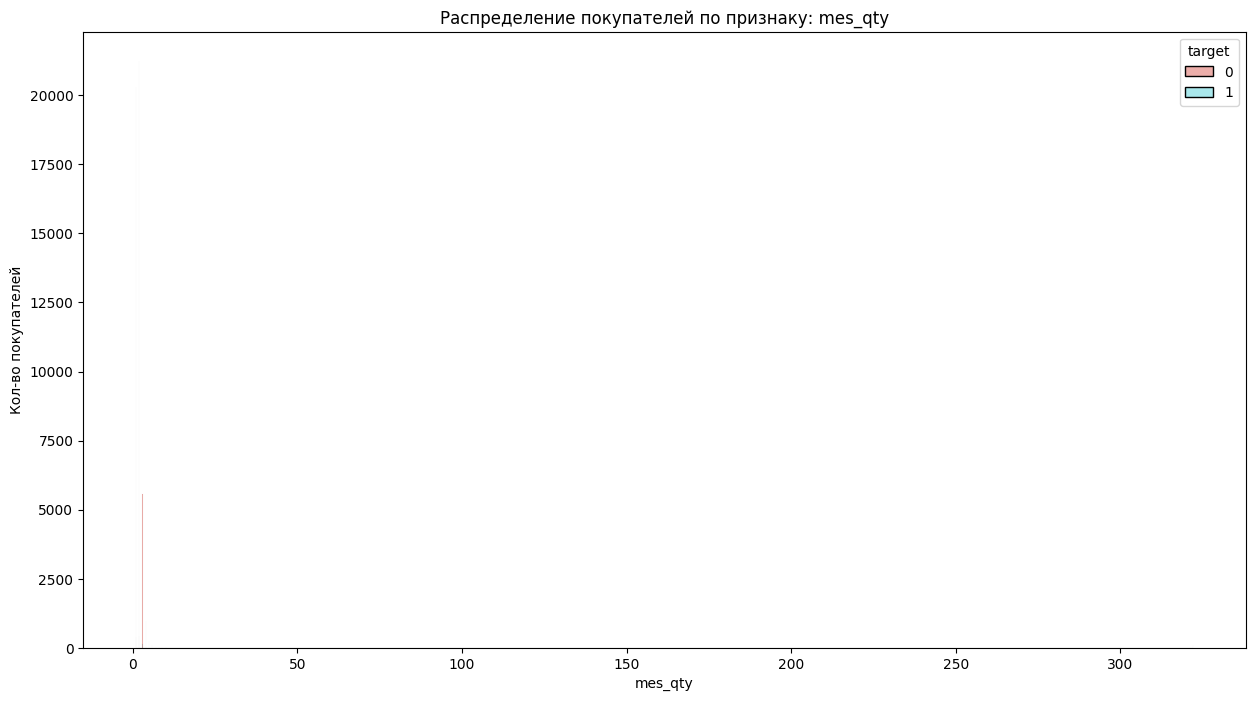

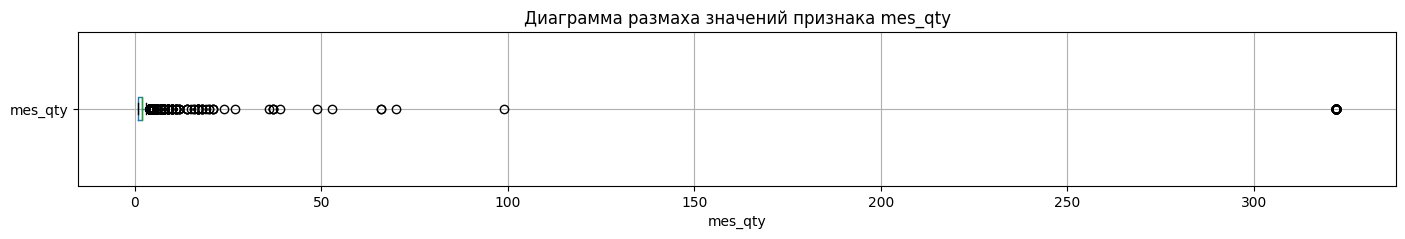

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: price_sum
count     49584.000000
mean       3270.393514
std        4367.796438
min           1.000000
25%        1137.000000
50%        2098.000000
75%        3995.000000
max      297954.000000
Name: price_sum, dtype: float64
Графики по признаку: price_sum


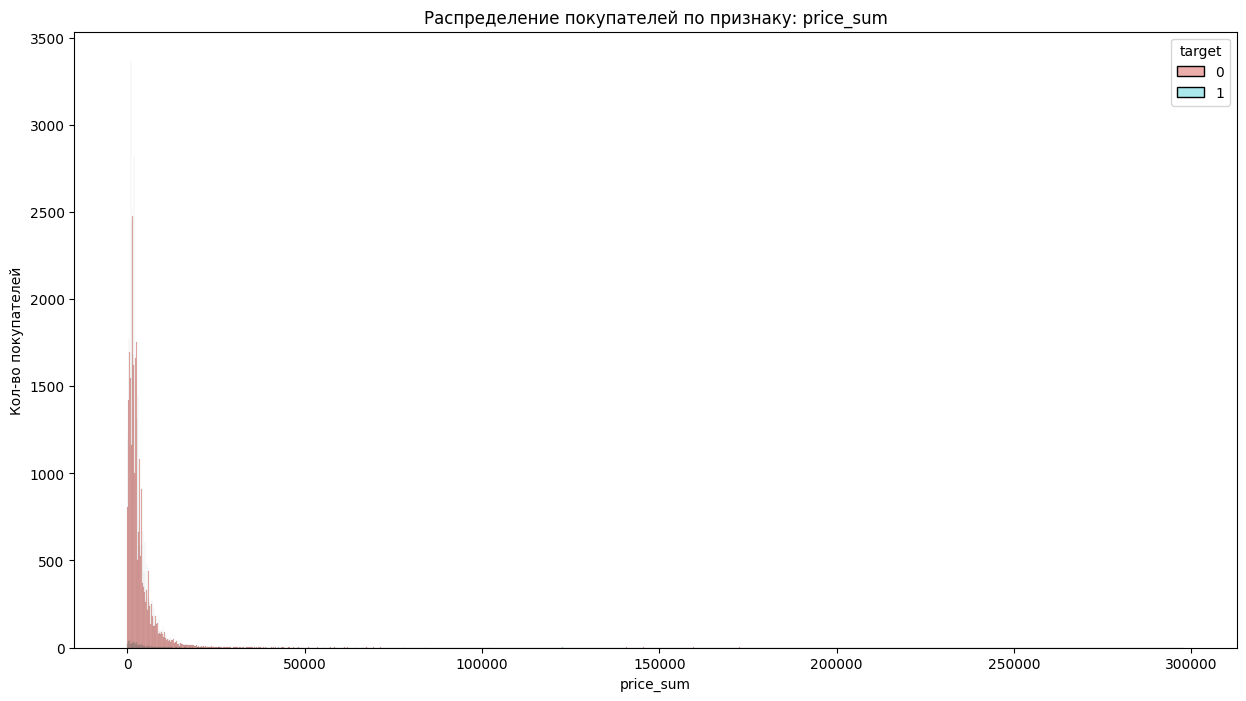

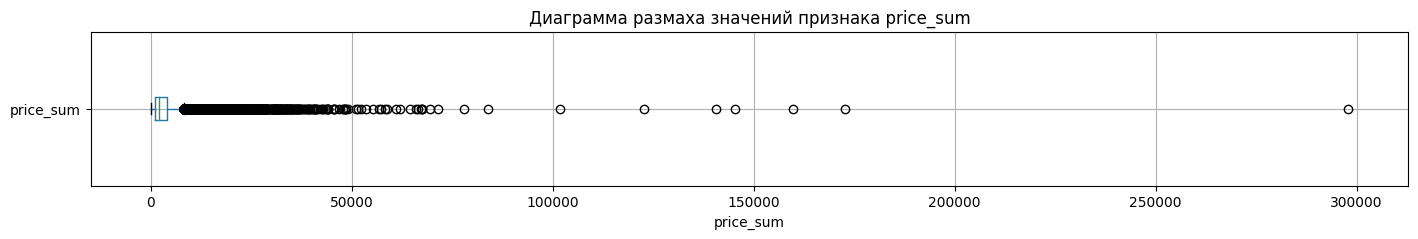

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: price_max
count    49584.000000
mean      1790.023576
std       1648.579949
min          1.000000
25%        910.000000
50%       1499.000000
75%       2199.000000
max      85499.000000
Name: price_max, dtype: float64
Графики по признаку: price_max


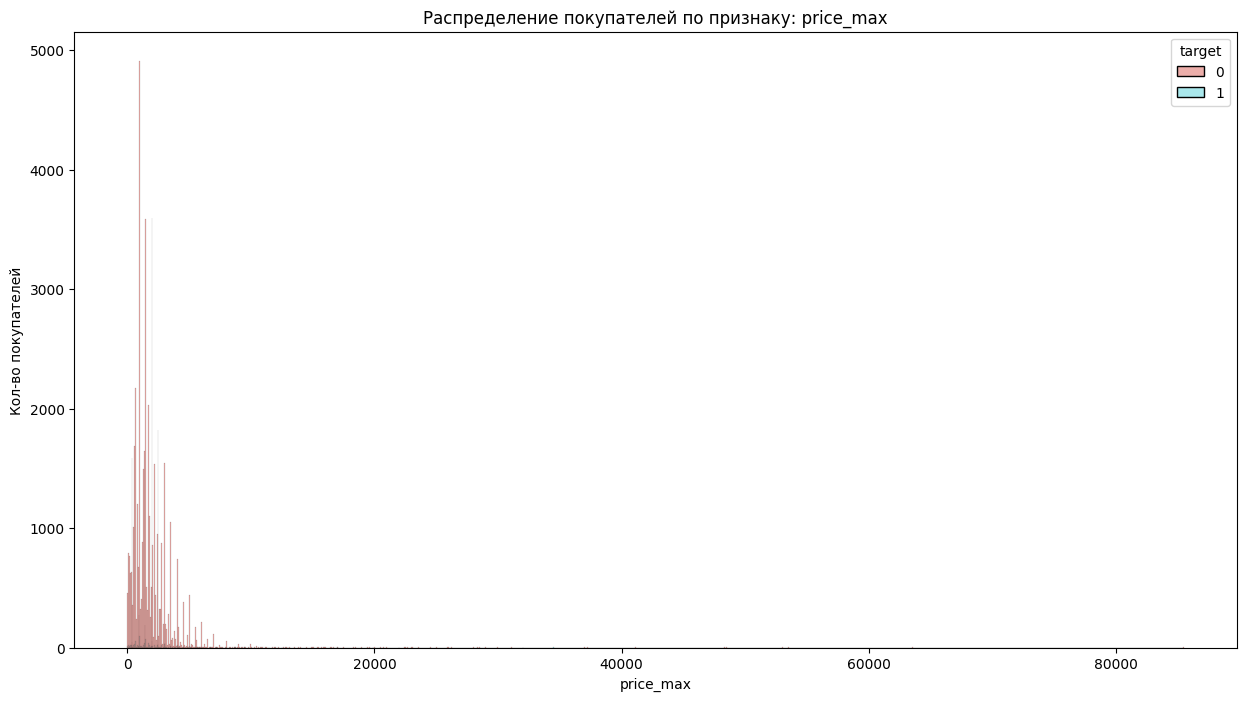

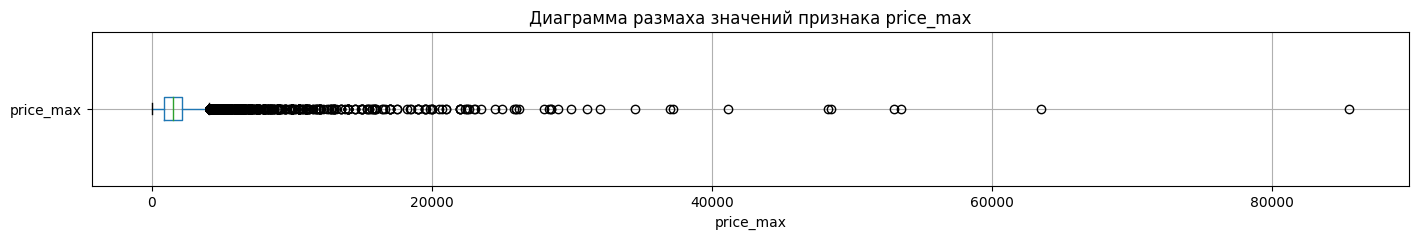

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: price_min
count    49584.000000
mean      1236.793562
std       1385.603207
min          1.000000
25%        399.000000
50%        999.000000
75%       1749.000000
max      53499.000000
Name: price_min, dtype: float64
Графики по признаку: price_min


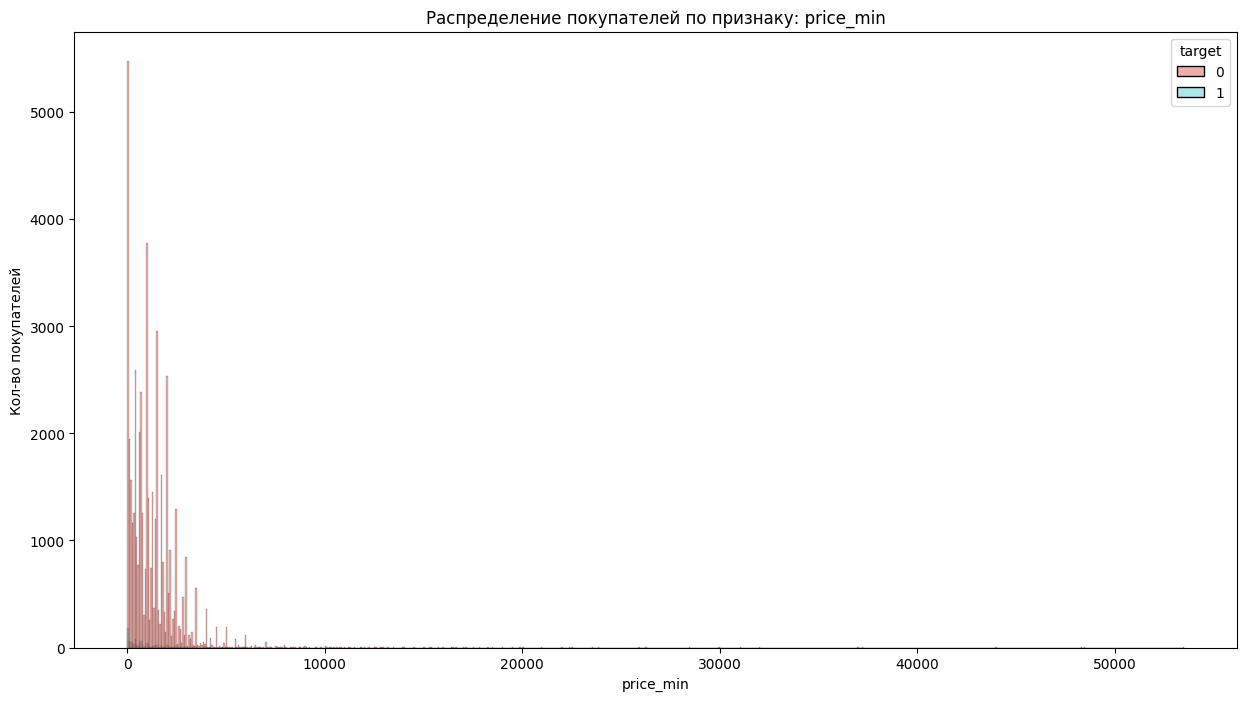

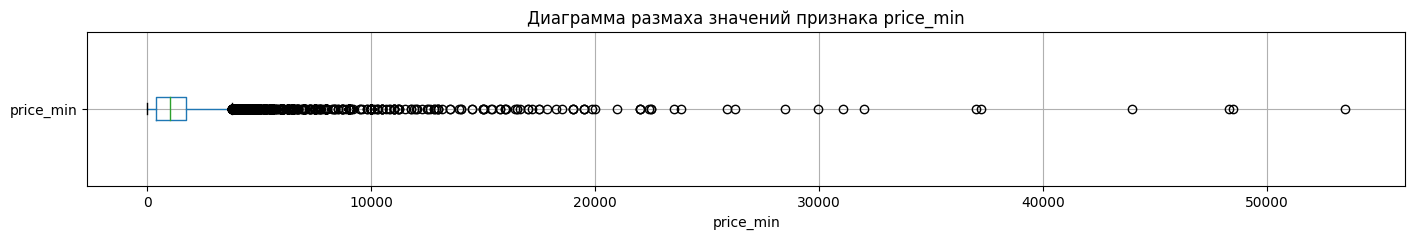

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: price_avg
count    49584.000000
mean      1490.281061
std       1389.655277
min          1.000000
25%        699.000000
50%       1249.000000
75%       1999.000000
max      53499.000000
Name: price_avg, dtype: float64
Графики по признаку: price_avg


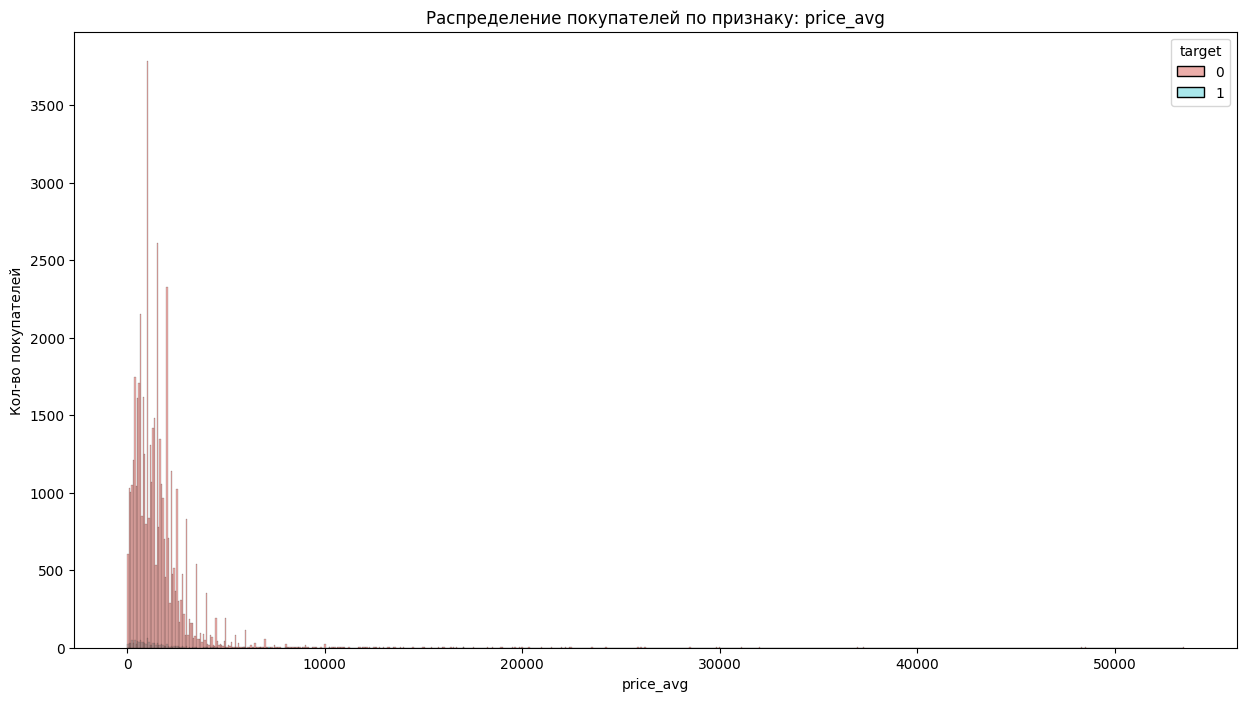

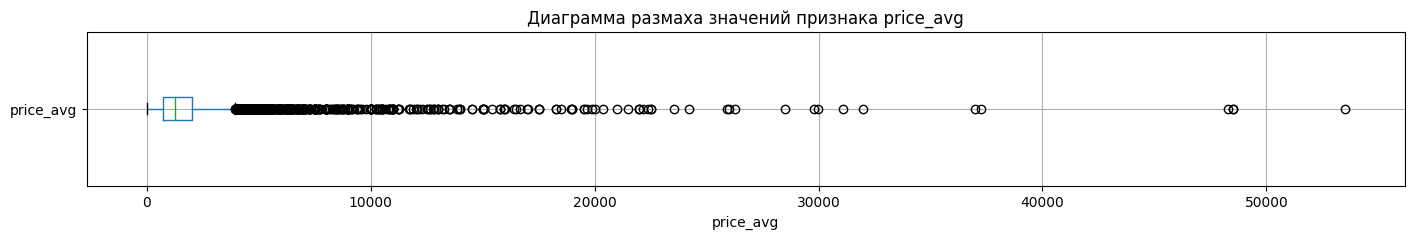

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: category_ids_qty
count    49584.000000
mean         3.924552
std          0.537798
min          0.000000
25%          4.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: category_ids_qty, dtype: float64
Графики по признаку: category_ids_qty


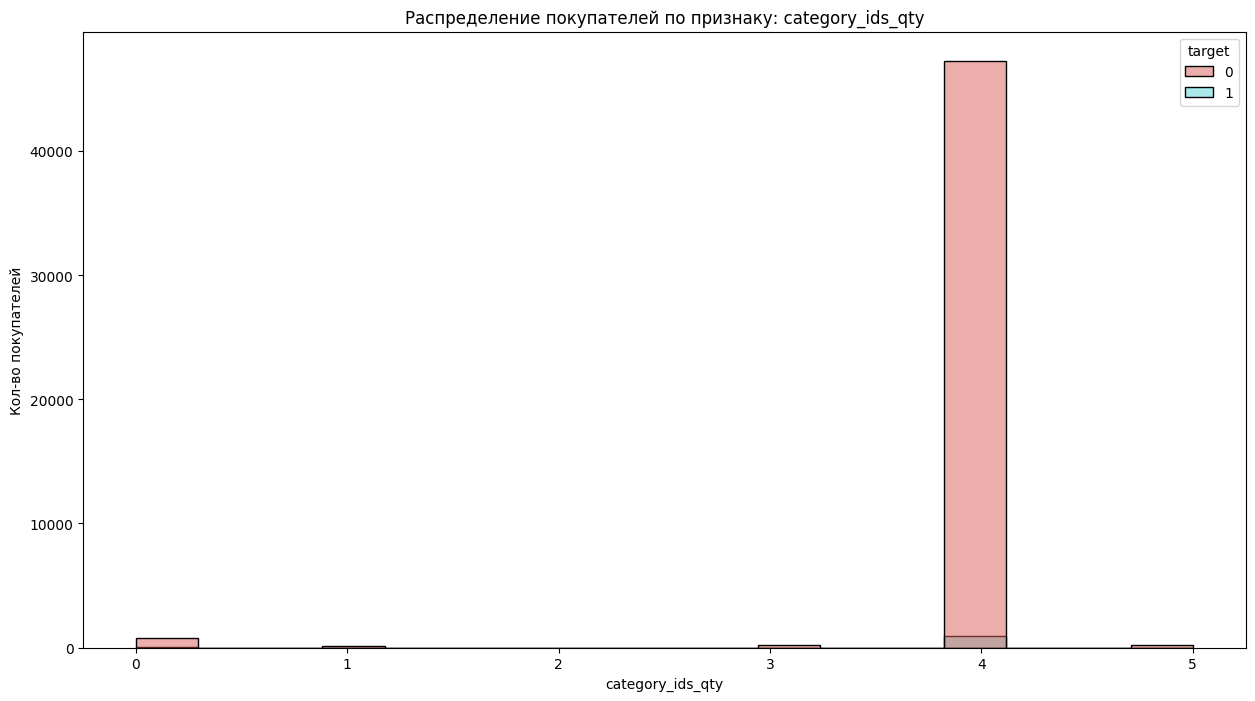

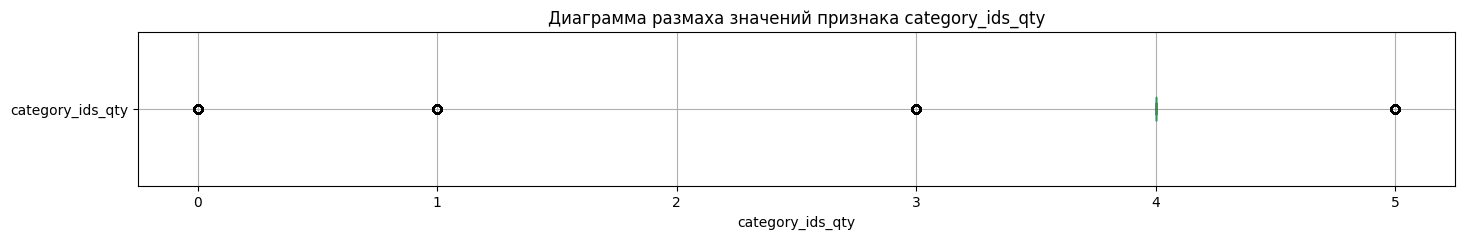

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: qty_sum
count    49584.000000
mean         2.615904
std          2.948858
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        161.000000
Name: qty_sum, dtype: float64
Графики по признаку: qty_sum


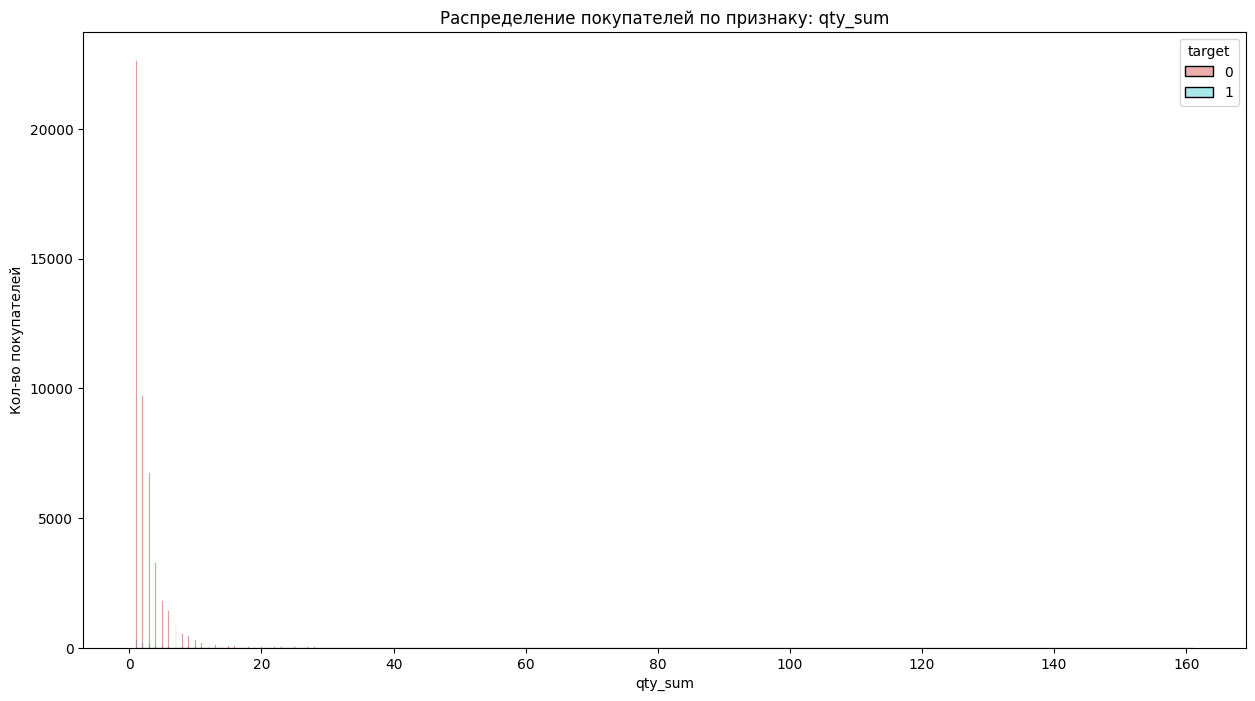

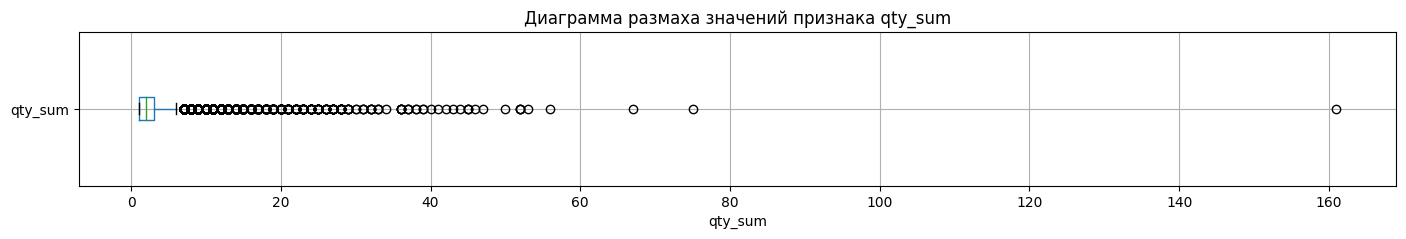

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: qty_avg
count    49584.000000
mean         1.009883
std          0.168167
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         19.000000
Name: qty_avg, dtype: float64
Графики по признаку: qty_avg


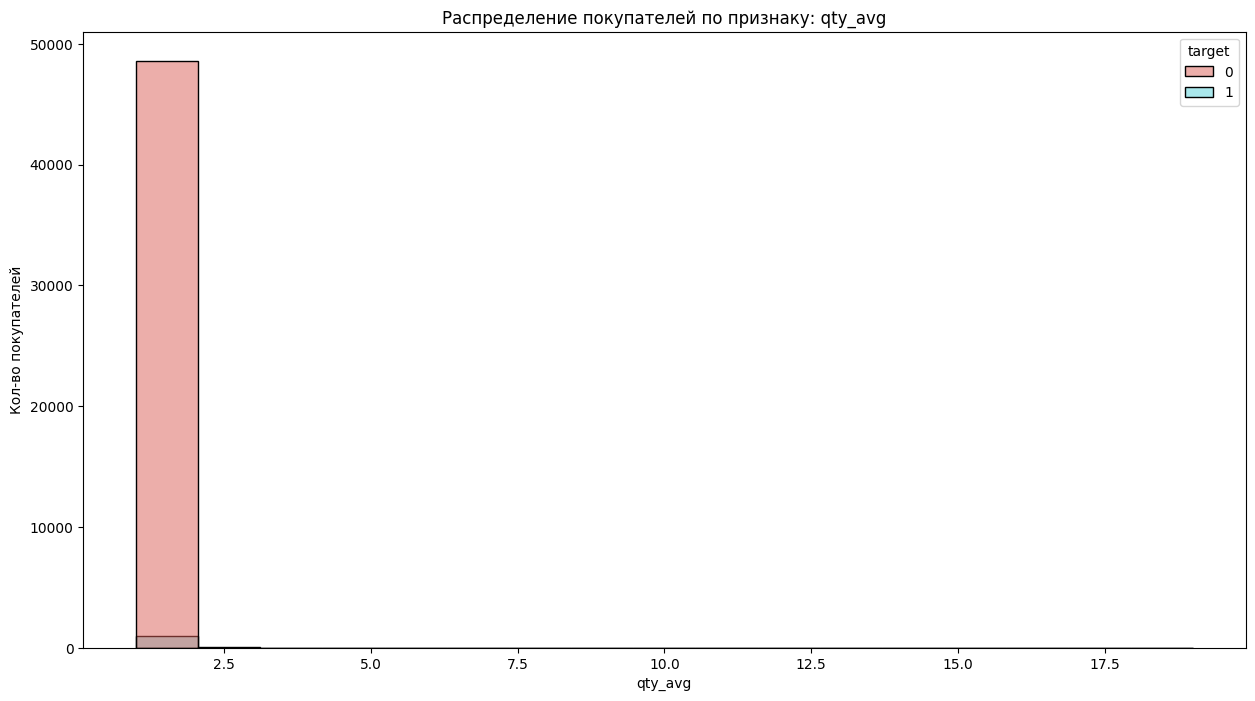

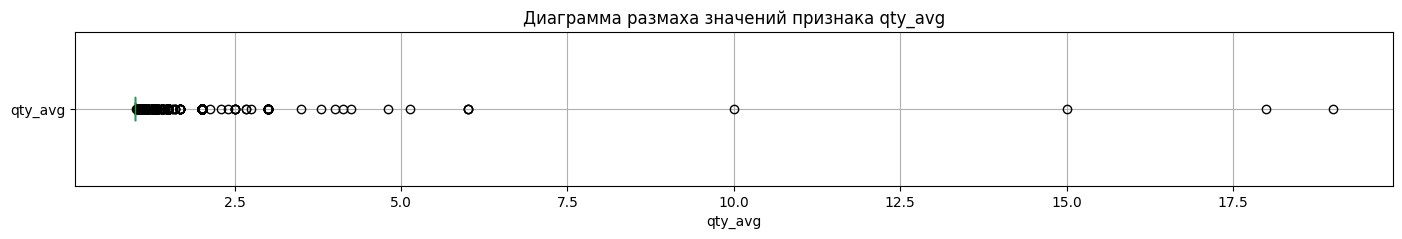

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: purch_year
count    49584.000000
mean      2022.591562
std          0.584893
min       2022.000000
25%       2022.000000
50%       2023.000000
75%       2023.000000
max       2024.000000
Name: purch_year, dtype: float64
Графики по признаку: purch_year


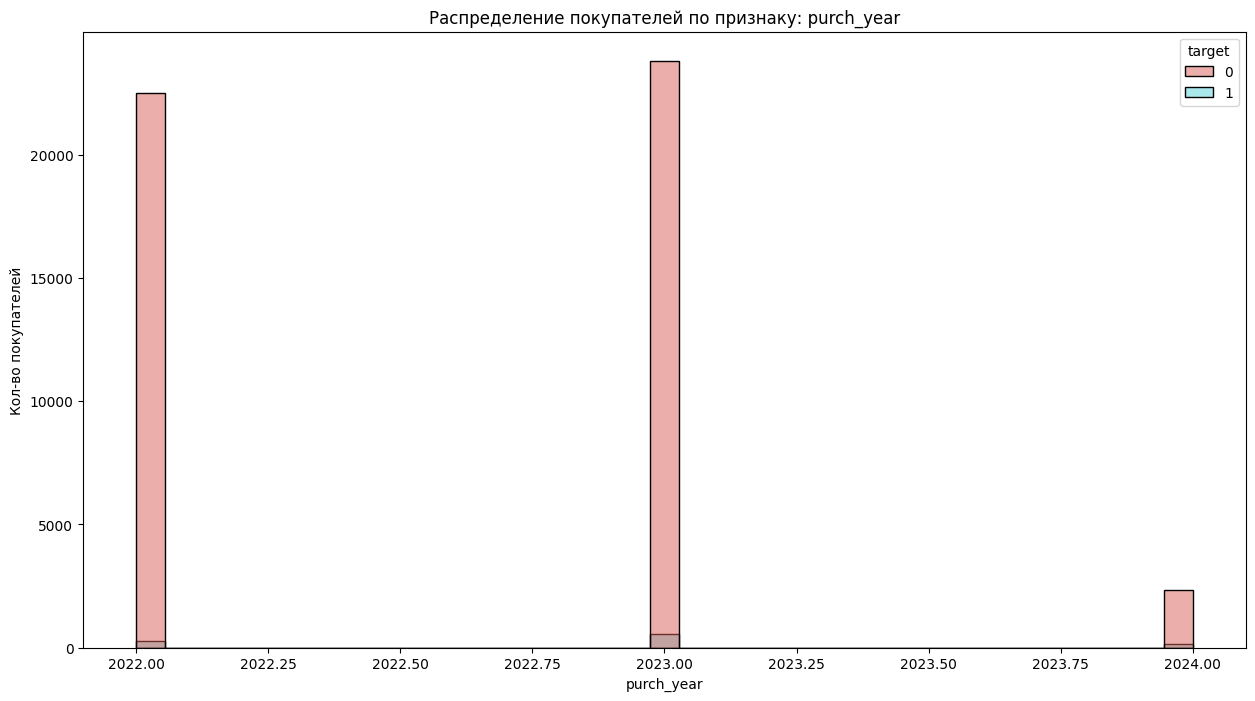

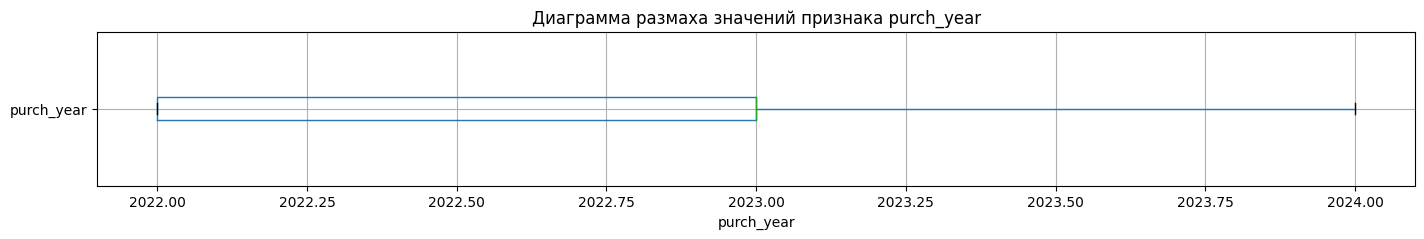

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Основные количественные характеристики признака: mes_year
count    49584.000000
mean      2022.597168
std          0.588151
min       2022.000000
25%       2022.000000
50%       2023.000000
75%       2023.000000
max       2024.000000
Name: mes_year, dtype: float64
Графики по признаку: mes_year


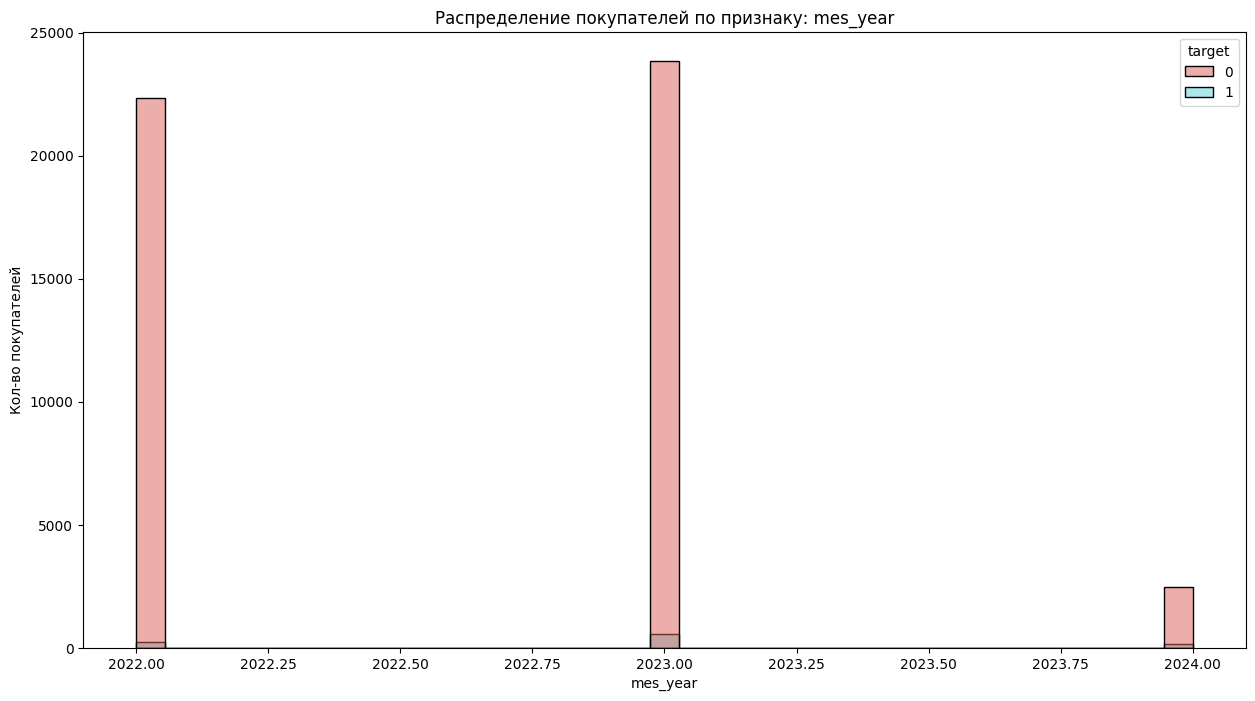

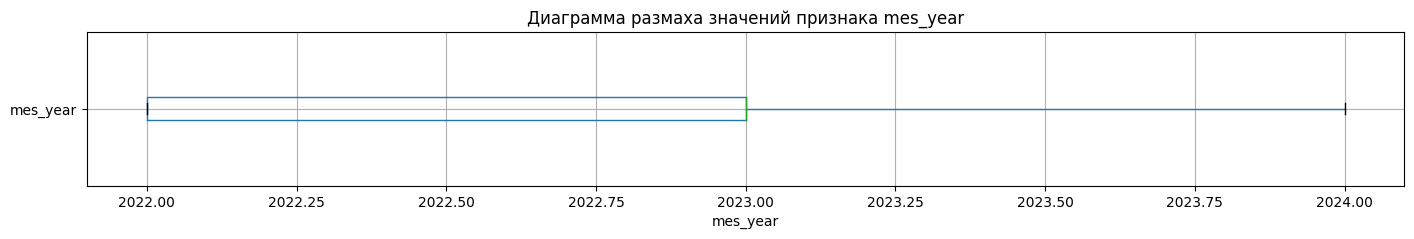

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -


In [510]:
for i in num_list:
    kol_an(final_data, i, 'target')
# применяем функцию к списку количественных признаков

Анализ признака target показывает, что в данных большой дисбаланс классов. У нас очень маленькое количество покупателей, совершивших покупки в течение 90 дней, по сравнению с не совершившими. Но каких-либо аномалий или выбросов нет. \
Признак mes_qty содержит в себе выбросы. Почти все клиенты получили не больше 2 рассылок, но есть 5 покупателей, которые совершили покупки после аномального количества сообщений - 322. Данные нельзя назвать ошибкой, вероятно, покупатели решить приобрести товары через большое количество времени и после множества рассылок. Не будем убирать эти данные из модели.

In [511]:
final_data.query('mes_qty > 100').head()
# смотрим на клиентов с аномальным количеством рассылок.

,target,last_purchase_date,event,channel,last_date_mes,mes_qty,price_sum,price_max,price_min,price_avg,category_ids_qty,qty_sum,qty_avg,purch_year,mes_year
client_id,,,,,,,,,,,,,,,
1515915625468066803,0,2022-09,click,email,2024-01,322.0,3097.0,1699.0,399.0,1032.33,4.0,3.0,1.0,2022,2024
1515915625468103897,0,2022-11,click,email,2024-01,322.0,169.0,99.0,70.0,84.50,4.0,2.0,1.0,2022,2024
1515915625468208022,0,2022-09,click,email,2024-01,322.0,2499.0,2499.0,2499.0,2499.00,4.0,1.0,1.0,2022,2024
1515915625468228554,0,2022-11,click,email,2024-01,322.0,1539.0,1539.0,1539.0,1539.00,4.0,1.0,1.0,2022,2024
1515915625468236938,0,2023-04,click,email,2024-01,322.0,1198.0,999.0,199.0,599.00,4.0,2.0,1.0,2023,2024


В данных по price_sum есть несколько больших значений, но явно выделяется аномалия в 297 954. Все остальные клиенты покупали сильно меньше. Поэтому для лучшей работы модели лучше удалить этот выброс из датасета. \
В данных по price_avg также есть несколько аномально высокий значений, но нельзя считать, что это некорректные данные. Оставим их без изменений. \
В признаке category_ids_qty мы видим, что большая часть клиентов покупала товары из 4 категорий, аномалий и выбросов нет. \
В признаке qty_sum, как и в сумме, мы видим несколько выбросов, но сильно выделяется один - с количеством 161 шт. Для лучшей работы модели уберем и его из данных. \
В признаке qty_avg есть также несколько выбросов, которые также нельзя считать аномалиями. Не будем ничего делать с этими данными.

In [512]:
final_data.query('price_sum > 200000')
# смотрим на клиента с очень большой суммой заказа

,target,last_purchase_date,event,channel,last_date_mes,mes_qty,price_sum,price_max,price_min,price_avg,category_ids_qty,qty_sum,qty_avg,purch_year,mes_year
client_id,,,,,,,,,,,,,,,
1515915625553309277,0,2023-12,purchase,mobile_push,2023-12,2.0,297954.0,85499.0,17849.0,29795.4,4.0,10.0,1.0,2023,2023


In [513]:
final_data = final_data.query('price_sum < 290000')
# убираем из датасета строку с выбросом по сумме заказа

Основные количественные характеристики признака: price_sum
count     49583.000000
mean       3264.450275
std        4162.521450
min           1.000000
25%        1137.000000
50%        2098.000000
75%        3995.000000
max      172763.000000
Name: price_sum, dtype: float64
Графики по признаку: price_sum


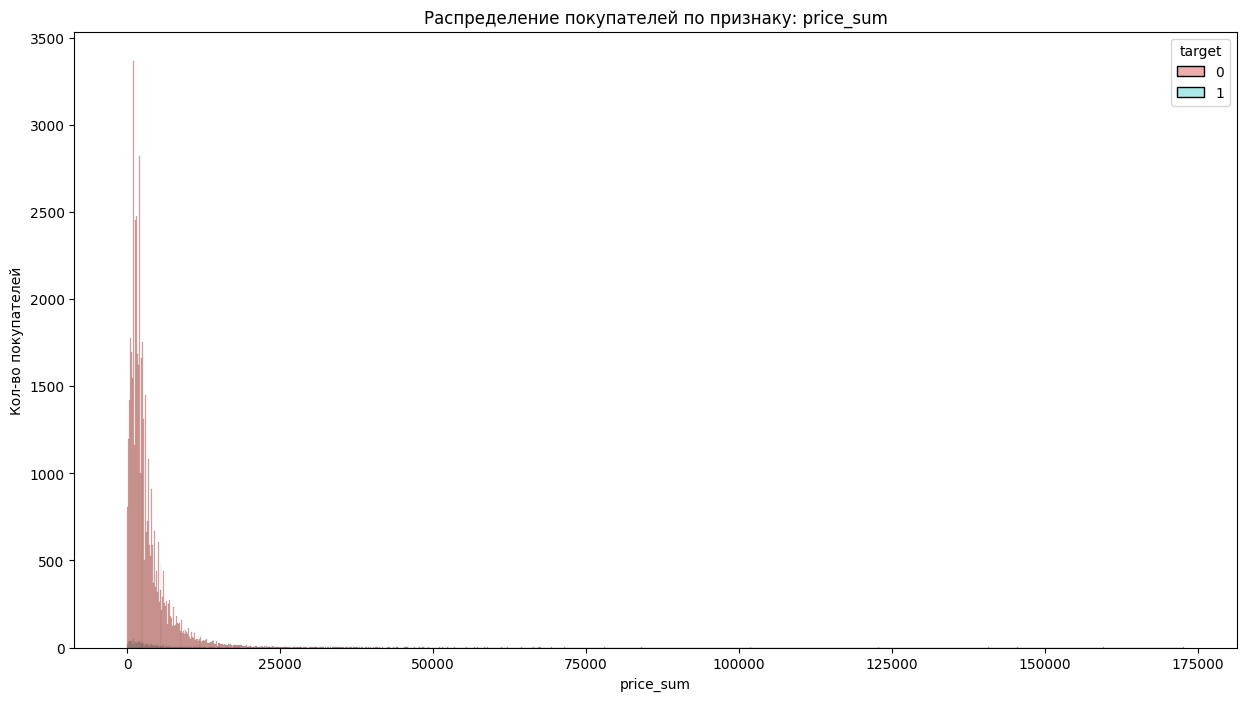

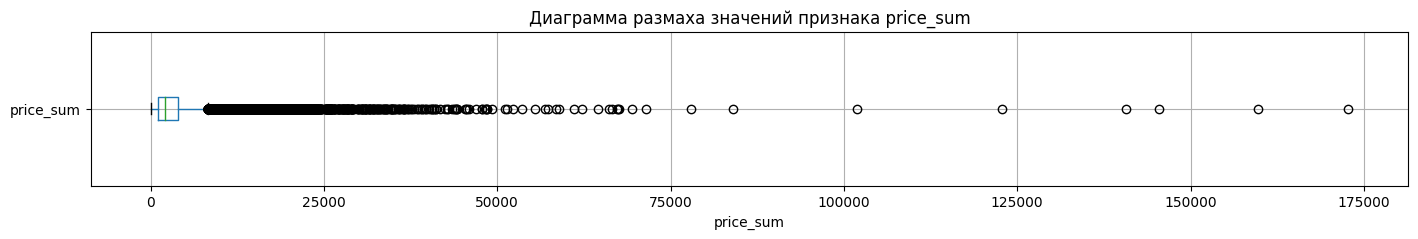

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -


In [514]:
kol_an(final_data, 'price_sum', 'target')
# еще раз смотрим на анализ признака price_sum без выброса

In [515]:
final_data.query('qty_sum > 100')
# смотрим на клиента с очень большим количеством товаров

,target,last_purchase_date,event,channel,last_date_mes,mes_qty,price_sum,price_max,price_min,price_avg,category_ids_qty,qty_sum,qty_avg,purch_year,mes_year
client_id,,,,,,,,,,,,,,,
1515915625853312319,0,2023-12,open,email,2023-12,6.0,140754.0,4999.0,7.0,902.27,4.0,161.0,1.03,2023,2023


In [516]:
final_data = final_data.query('qty_sum < 100')
# убираем из датасета строку с выбросом по количеству товаров

Основные количественные характеристики признака: qty_sum
count    49582.000000
mean         2.612561
std          2.861652
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         75.000000
Name: qty_sum, dtype: float64
Графики по признаку: qty_sum


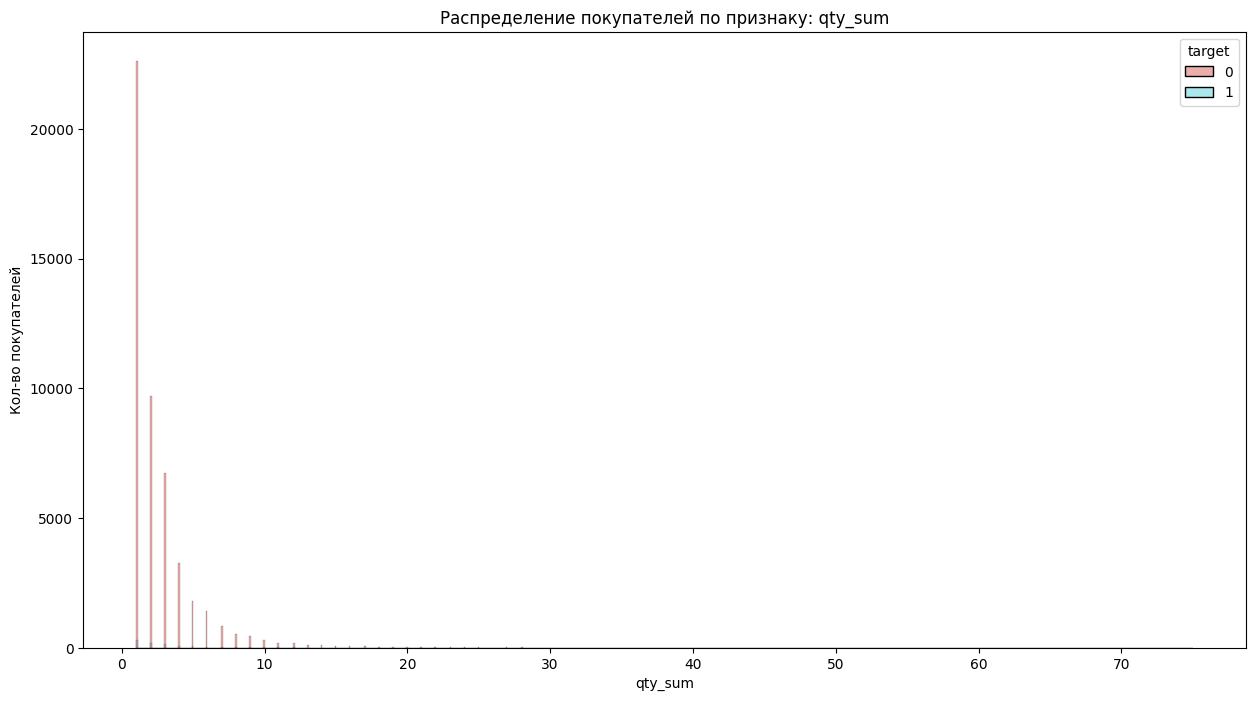

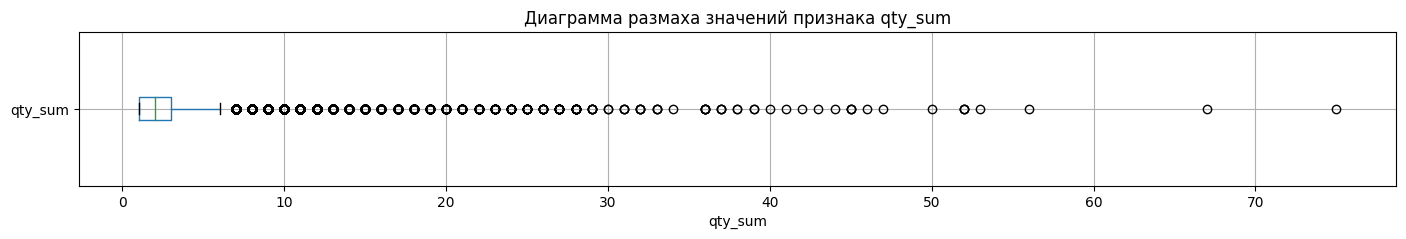

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -


In [517]:
kol_an(final_data, 'qty_sum', 'target')
# еще раз смотрим на анализ признака qty_sum без выброса

В признаках с годом последней покупки (purch_year) и годом последней рассылки (mes_year) нет каких-либо выбросов. Мы видим, что в данных представлена информация о покупателях за 3 года - 2022, 2023 и 2024. Больше всего покупок и рассылок по пользователям датасета было в 2023 году.

### Анализ категориальных признаков.

In [518]:
col_list = final_data.select_dtypes(exclude=['number']).columns.tolist()
# определяем список категориальных признаков датасета
col_list
# смотрим список категориальных признаков датасета

['last_purchase_date', 'event', 'channel', 'last_date_mes']

В списке категориальных признаков есть параметры с большим количеством уникальных значений. Применим функцию анализа категорий только для признаков event и  channel.

Распределение покупателей по признаку: last_purchase_date
2023-06    5225
2022-06    4596
2022-11    3918
2022-12    3825
2022-07    3822
2023-04    3632
2022-08    3149
2023-07    2420
2023-05    2409
2023-03    2386
2023-12    2309
2024-01    1671
2022-09    1609
2022-05    1544
2023-08    1439
2023-11    1421
2023-09    1024
2024-02     820
2023-01     799
2023-10     753
2023-02     531
2022-10     280
Name: last_purchase_date, dtype: int64


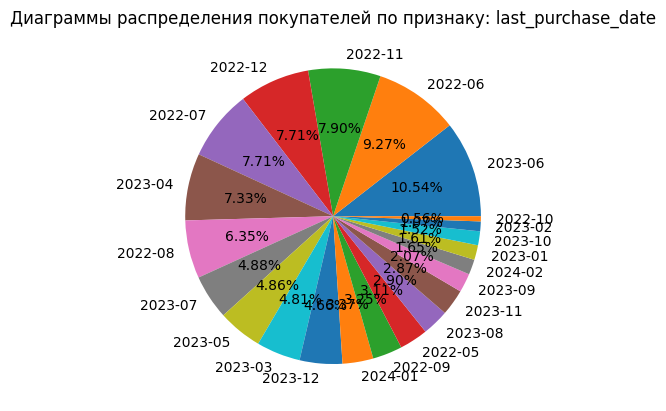

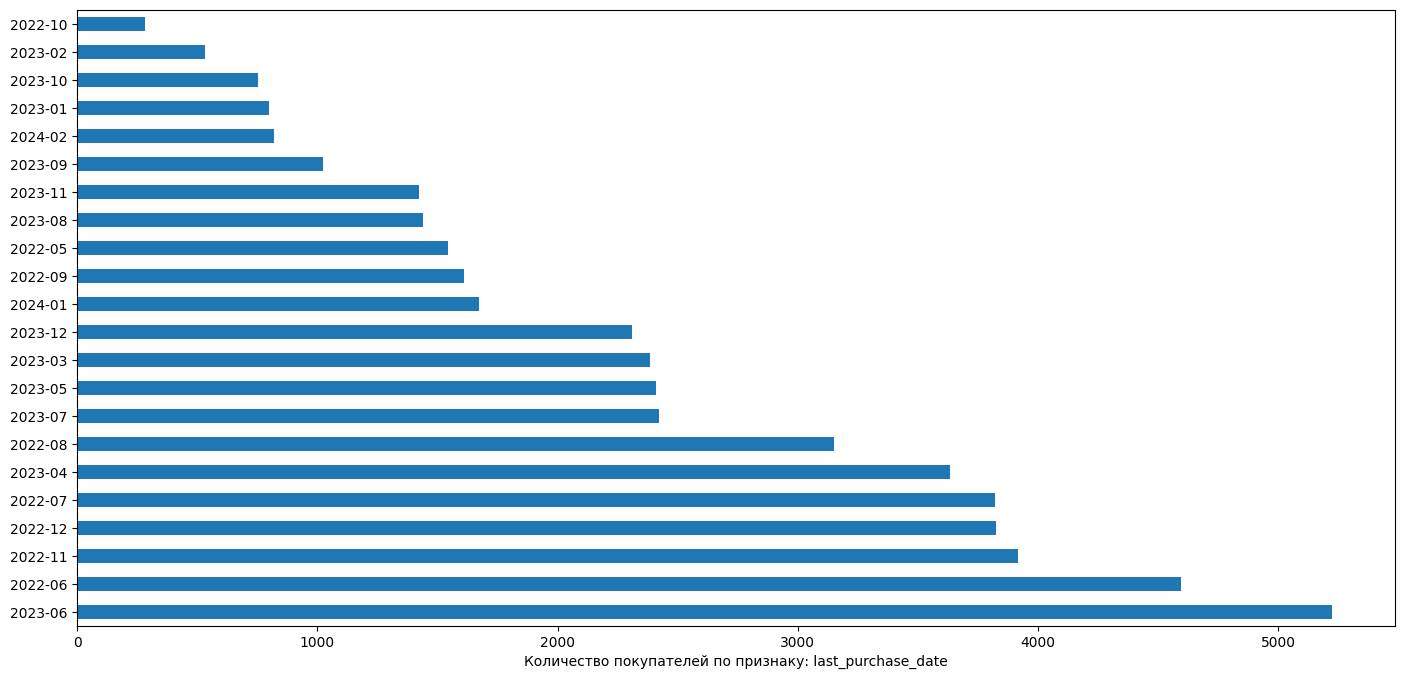

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Распределение покупателей по признаку: event
purchase       21481
send           10510
click          10409
open            7148
unsubscribe       22
complain          12
Name: event, dtype: int64


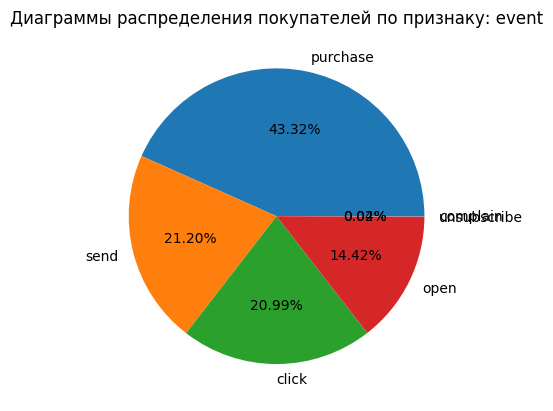

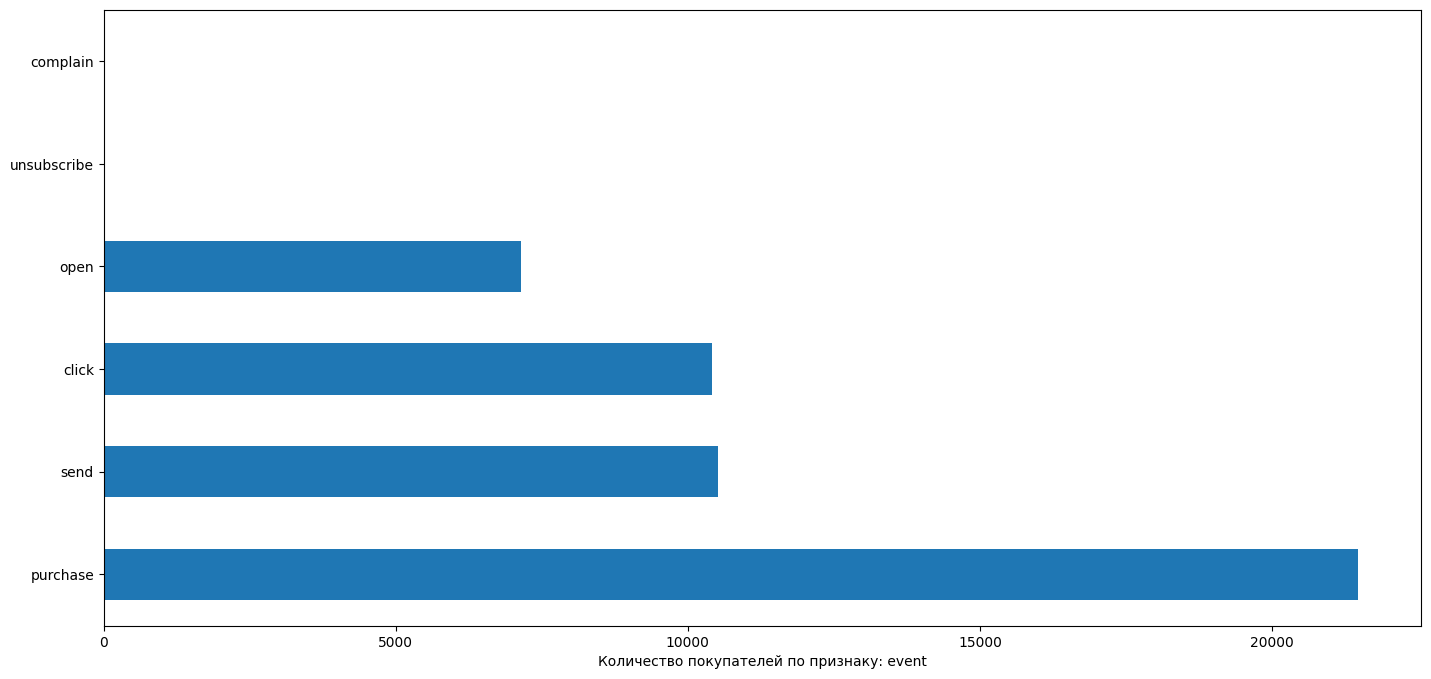

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Распределение покупателей по признаку: channel
email          34156
mobile_push    15426
Name: channel, dtype: int64


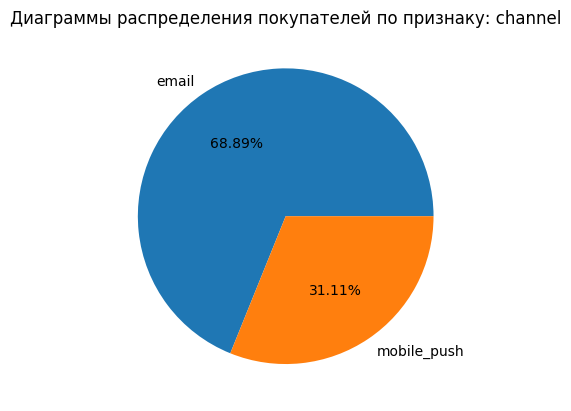

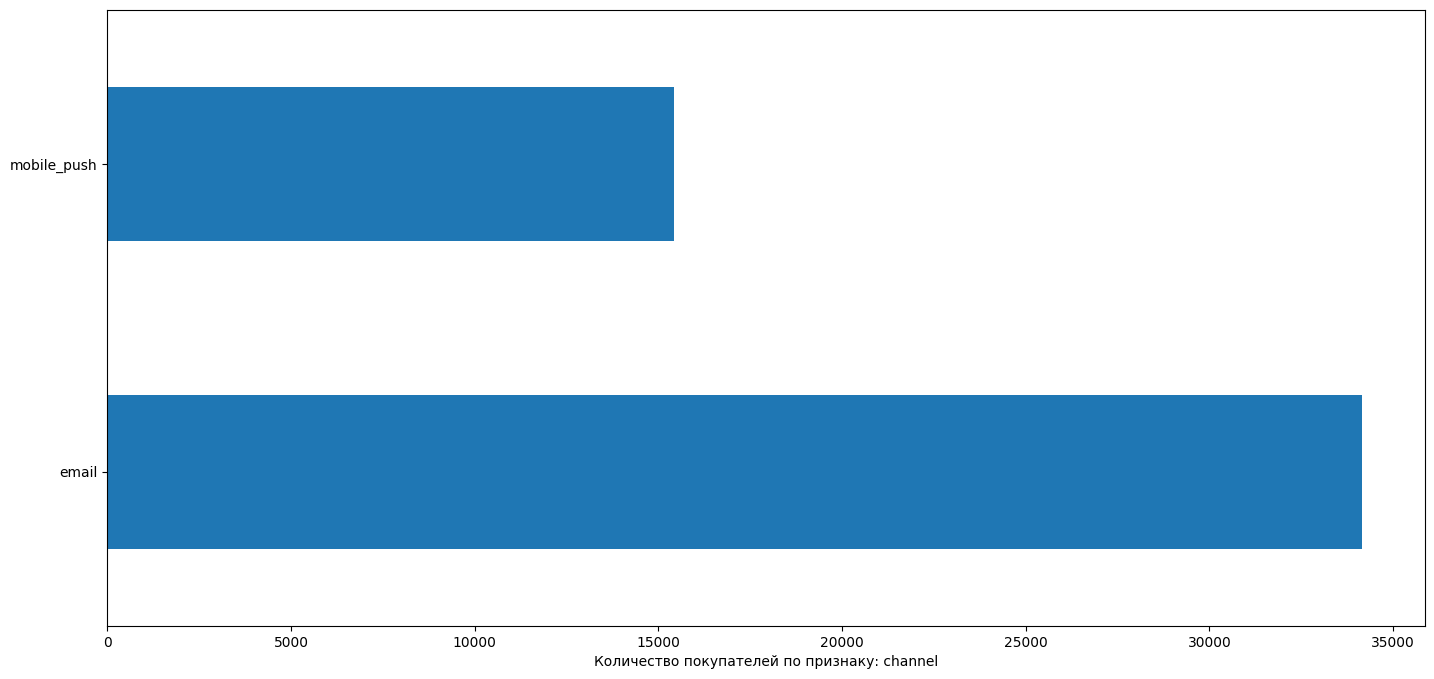

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -
Распределение покупателей по признаку: last_date_mes
2023-06    5168
2022-06    4545
2022-11    3898
2022-12    3777
2022-07    3771
2023-04    3560
2022-08    3147
2023-05    2468
2023-07    2461
2023-03    2359
2023-12    2295
2024-01    1777
2022-09    1643
2022-05    1500
2023-08    1452
2023-11    1433
2023-09    1034
2023-01     856
2024-02     835
2023-10     745
2023-02     553
2022-10     305
Name: last_date_mes, dtype: int64


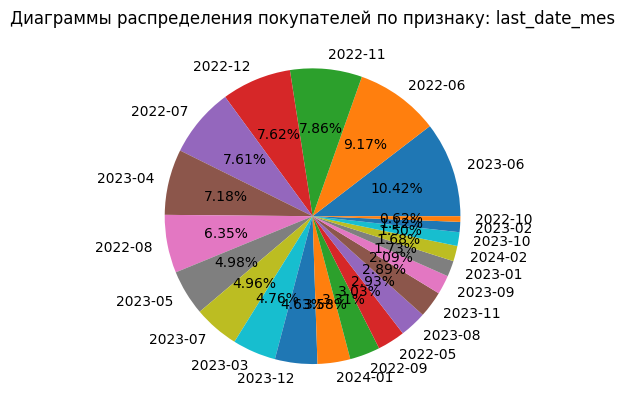

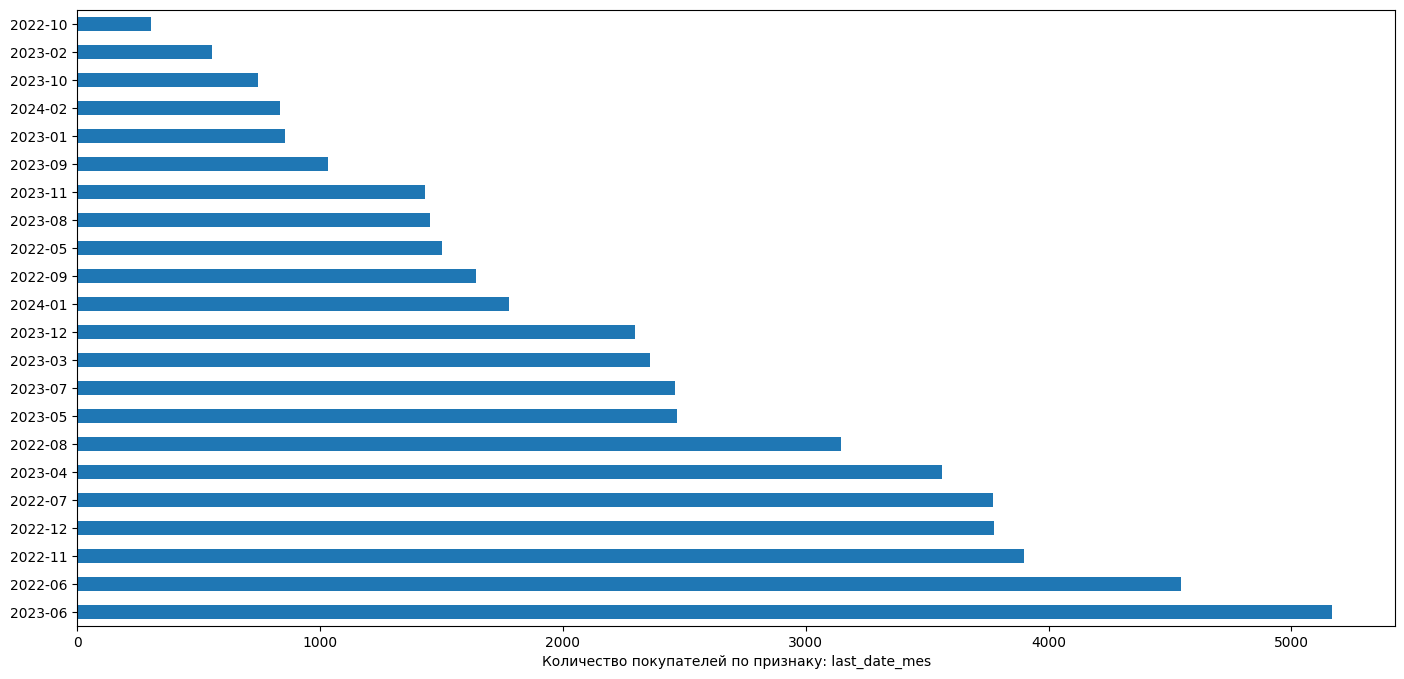

- - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - - - - - - - - - - - -  - - - - - - - -


In [519]:
for i in col_list:
    kat_an(final_data, i)
# применяем функцию к списку категориальных признаков

Анализ категориальных признаков позволяет сделать следующие выводы:
1. Больше всего покупок клиенты делали в июне 2023 (10.54% клиентов) и в июне 2022 (9.27% клиентов). Что говорит о том, что летом покупательская активность становится выше (данных за 2024 год просто слишком мало, чтобы попасть в топ).
2. Из событий event мы видим, что 43.32% клиентов совершили покупку после рассылки, 21.20% отправили рассылку, 20.99% совершили переход по клику, а 14.42% просто открыли сообщение.  И очень маленький процент покупателей отписались или пожаловались на рассылку, что может говорить об общей эффективности механизма рассылок.
3. Основной канал распространения - email. 68.89% рассылок прошло через электронную почту, и только 31.11% прошло через мобильные пуш-уведомления.
4. Объемы последних рассылок соответствуют данным о покупках. Больше всего рассылок в июне 2023 (10.42%) и 2022 (9.17%) годов. Есть явная зависимость между временем рассылки и временем покупки.

### Корреляционный анализ признаков.

In [520]:
phik_matrix = final_data.phik_matrix(interval_cols=num_list)
phik_matrix
# строим матрицу корреляции Фи

,target,last_purchase_date,event,channel,last_date_mes,mes_qty,price_sum,price_max,price_min,price_avg,category_ids_qty,qty_sum,qty_avg,purch_year,mes_year
target,1.000000,0.121415,0.007015,0.038701,0.120909,0.000000,0.050497,0.011681,0.000000,0.000000,0.000000,0.096777,0.000000,0.050510,0.049487
last_purchase_date,0.121415,1.000000,0.200863,0.527607,0.999930,0.064168,0.073245,0.072579,0.065026,0.071977,0.203010,0.101400,0.021248,1.000000,0.991138
event,0.007015,0.200863,1.000000,0.418145,0.235842,0.061089,0.000000,0.005849,0.009247,0.003919,0.015830,0.018725,0.000000,0.197454,0.203522
channel,0.038701,0.527607,0.418145,1.000000,0.520526,0.023047,0.010923,0.049319,0.037886,0.049343,0.027360,0.038170,0.024093,0.172865,0.167090
last_date_mes,0.120909,0.999930,0.235842,0.520526,1.000000,0.214350,0.070071,0.070844,0.063622,0.070840,0.202155,0.101392,0.019140,0.991250,1.000000
mes_qty,0.000000,0.064168,0.061089,0.023047,0.214350,1.000000,0.018150,0.000000,0.000000,0.000000,0.026446,0.097701,0.000000,0.013743,0.164228
price_sum,0.050497,0.073245,0.000000,0.010923,0.070071,0.018150,1.000000,0.737389,0.807999,0.483294,0.000000,0.672571,0.000000,0.078628,0.077799
price_max,0.011681,0.072579,0.005849,0.049319,0.070844,0.000000,0.737389,1.000000,0.863437,0.863620,0.000000,0.061668,0.000000,0.049650,0.048571
price_min,0.000000,0.065026,0.009247,0.037886,0.063622,0.000000,0.807999,0.863437,1.000000,0.979754,0.000000,0.000000,0.000000,0.051957,0.050668
price_avg,0.000000,0.071977,0.003919,0.049343,0.070840,0.000000,0.483294,0.863620,0.979754,1.000000,0.003523,0.000000,0.000000,0.040385,0.039488


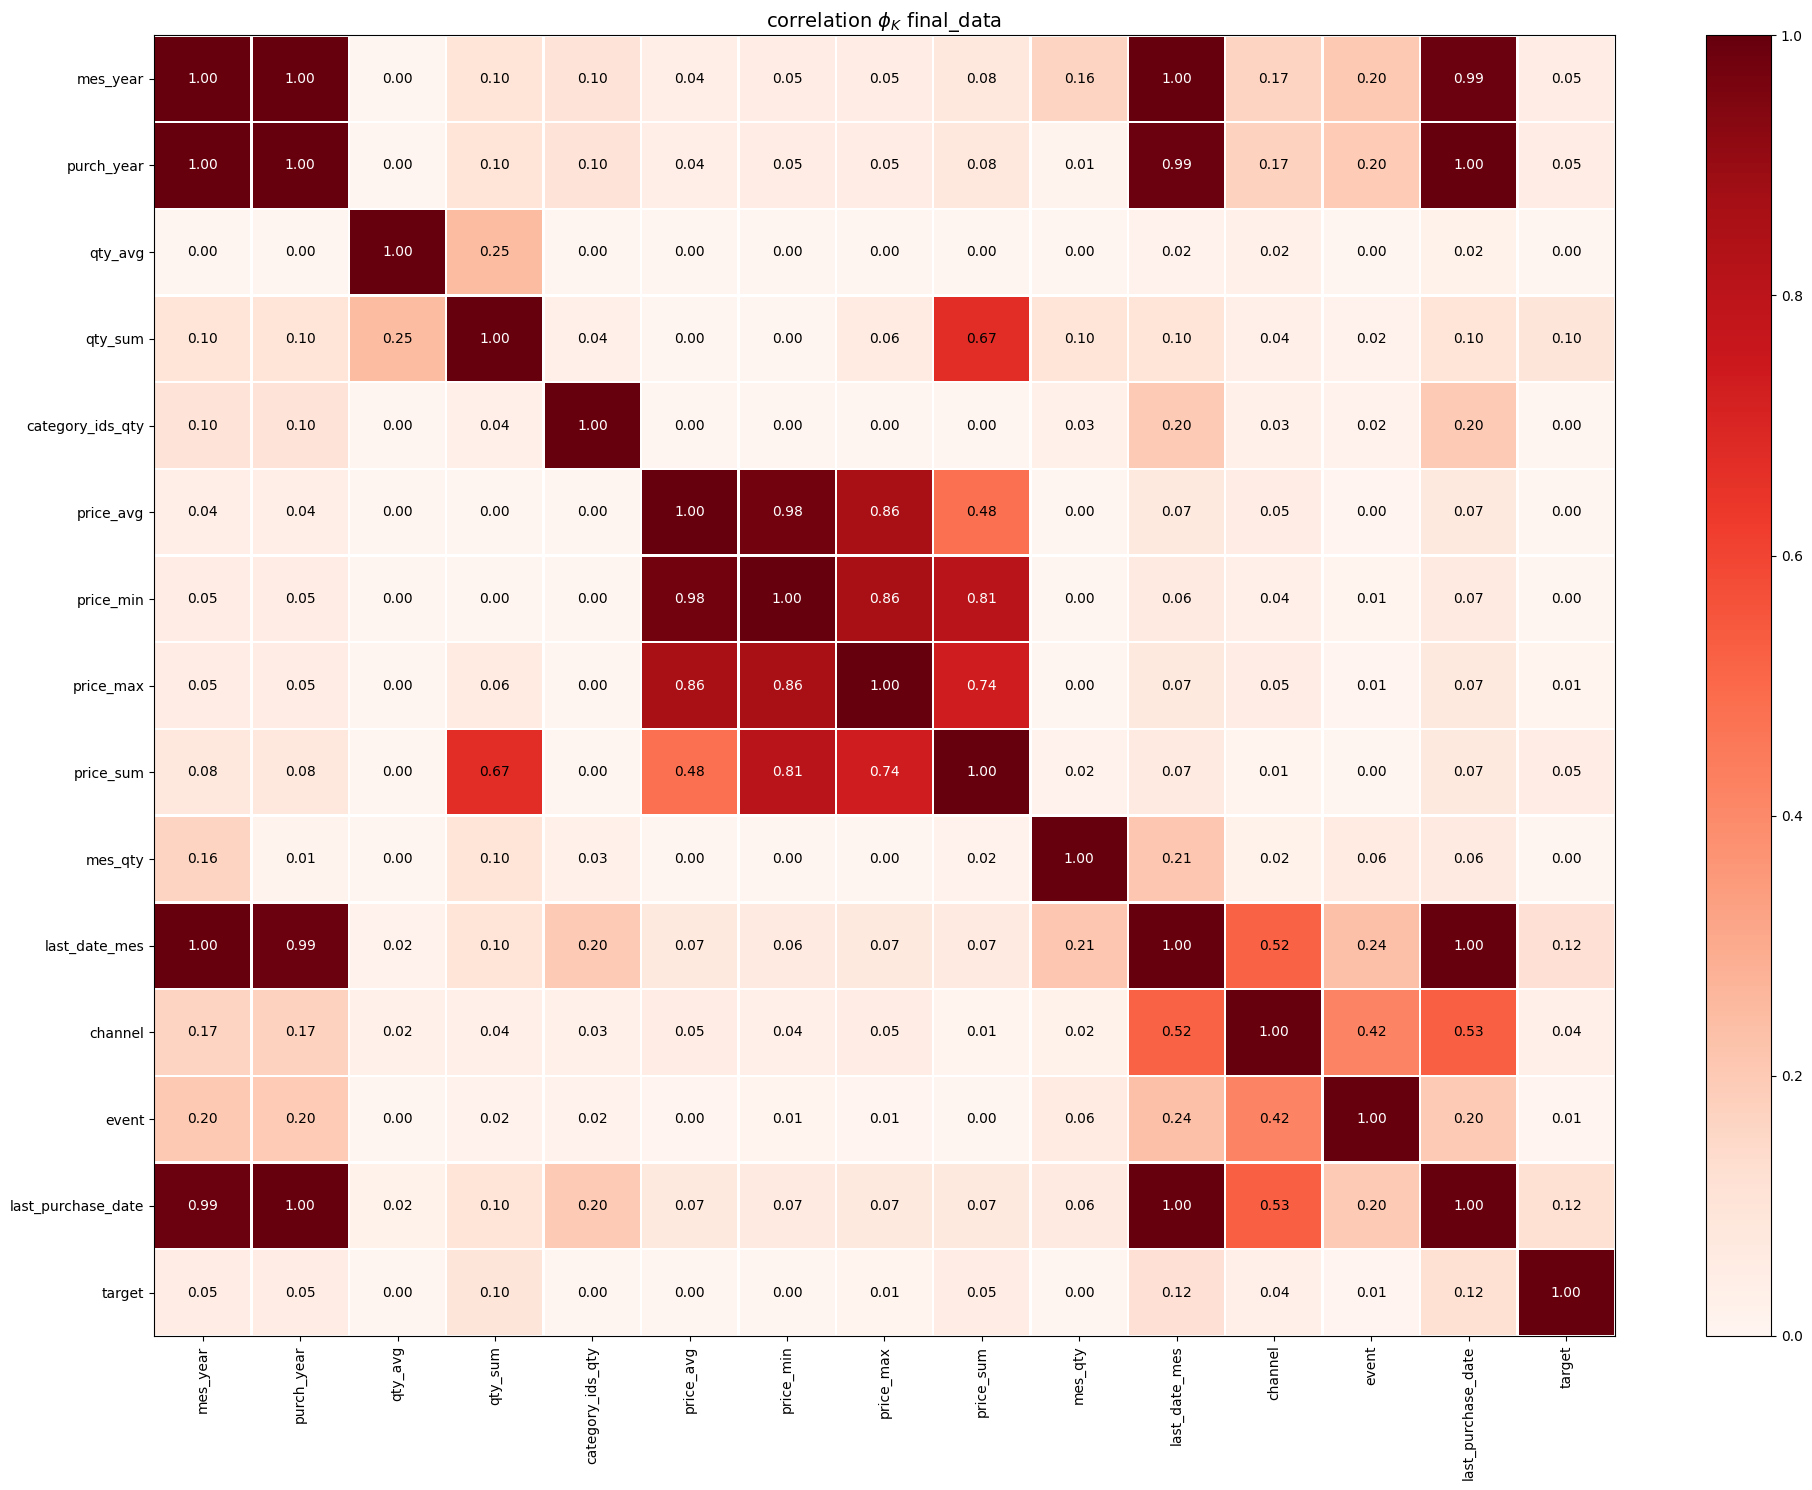

In [521]:
phik_overview = final_data.phik_matrix(interval_cols=num_list)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Reds',
    title=r'correlation $\phi_K$ final_data',
    figsize=(20, 15)
) 
# рисуем матрицу корреляции для final_data

Корреляционный анализ, ожидаемо, показывает наличие мультиколлинеарности между признаками mes_year, purch_year, last_purchase_date и last_date_mes. Оставим в наборе для модели только last_purchase_date - данные о последних покупках имеет один из самых высоких коэффициентов корреляции с целевым признаком (0.12). Такой же коэффициент и у last_date_mes, но факт покупки видется более важным признаком для предсказания следующих покупок, чем факт отправки рассылки. \
Если же смотреть на линейные зависимости входных признаков с целевым target - мы видим, что зависимость в целом достаточно мала, а по ряду признаков сотавляет 0.00. Такие признаки не принесут пользы для работы моделей, также уберем их из входных данных (это признаки: qty_avg, category_ids_qty, price_avg и mes_qty).

### Удаление неинформативных признаков.

In [555]:
model_data = final_data.drop(['mes_year', 'purch_year', 'last_date_mes', 'qty_avg', 'category_ids_qty', 'price_avg', 'mes_qty'], axis=1)
# убираем из данных для модели ненужные признаки
model_data.head()
# смотрим, что получилось

,target,last_purchase_date,event,channel,price_sum,price_max,price_min,qty_sum
client_id,,,,,,,,
1515915625468060902,0,2022-05,send,email,4795.0,1999.0,199.0,5.0
1515915625468061003,1,2023-01,send,email,14135.0,3499.0,1749.0,6.0
1515915625468061100,0,2024-02,purchase,mobile_push,1049.0,1049.0,1049.0,1.0
1515915625468061170,0,2023-06,click,email,14102.0,2699.0,7.0,8.0
1515915625468061514,0,2022-07,purchase,email,999.0,999.0,999.0,1.0


In [556]:
print('Явных дубликатов в датасете:', model_data.duplicated().sum())
# смотрим, появились ли явные дубликаты в данных после удаления части признаков

Явных дубликатов в датасете: 17155


In [557]:
model_data = model_data.drop_duplicates(keep='first')
# удаляем полные дубликаты строк

print('Явных дубликатов в датасете после обработки:', model_data.duplicated().sum())
# смотрим, что получилось

Явных дубликатов в датасете после обработки: 0


### Выводы по исследовательскому анализу.

На данном этапе проекта мы провели исследовательский анализ финального датасета. Сначала мы проанализировали количественные признаки датасета.

Анализ признака target показывает, что в данных большой дисбаланс классов. У нас очень маленькое количество покупателей, совершивших покупки в течение 90 дней, по сравнению с не совершившими. Но каких-либо аномалий или выбросов нет. \
Признак mes_qty содержит в себе выбросы. Почти все клиенты получили не больше 2 рассылок, но есть 5 покупателей, которые совершили покупки после аномального количества сообщений - 322. Данные нельзя назвать ошибкой, вероятно, покупатели решить приобрести товары через большое количество времени и после множества рассылок. Решили не убирать эти данные из модели. \
В данных по price_sum обнаружено несколько выбросов, но было решено удалить только один с аномально высокой суммой почти 300 тыс.
В данных по price_avg также обнаружено несколько аномально высокий значений, но нельзя считать, что это некорректные данные. Оставили их без изменений. \
В признаке category_ids_qty мы видим, что большая часть клиентов покупала товары из 4 категорий, аномалий и выбросов нет.
В признаке qty_sum, как и в сумме, мы видим несколько выбросов, но сильно выделяется один - с количеством 161 шт. Для лучшей работы модели убрали и его из данных. В признаке qty_avg есть также несколько выбросов, которые также нельзя считать аномалиями. \
В признаках с годом последней покупки (purch_year) и годом последней рассылки (mes_year) нет каких-либо выбросов. Мы видим, что в данных представлена информация о покупателях за 3 года - 2022, 2023 и 2024. Больше всего покупок и рассылок по пользователям датасета было в 2023 году.

Анализ категориальных признаков позволяет сделать следующие выводы:
- Больше всего покупок клиенты делали в июне 2023 (10.54% клиентов) и в июне 2022 (9.27% клиентов). Что говорит о том, что летом покупательская активность становится выше (данных за 2024 год просто слишком мало, чтобы попасть в топ).
- Из событий event мы видим, что 43.32% клиентов совершили покупку после рассылки, 21.20% отправили рассылку, 20.99% совершили переход по клику, а 14.42% просто открыли сообщение. И очень маленький процент покупателей отписались или пожаловались на рассылку, что может говорить об общей эффективности механизма рассылок.
- Основной канал распространения - email. 68.89% рассылок прошло через электронную почту, и только 31.11% прошло через мобильные пуш-уведомления.
- Объемы последних рассылок соответствуют данным о покупках. Больше всего рассылок в июне 2023 (10.42%) и 2022 (9.17%) годов. Есть явная зависимость между временем рассылки и временем покупки.

Далее мы провели корреляционный анализ признаков финального датасета. \
Мы обнаружили мультиколлинеарность между признаками mes_year, purch_year, last_purchase_date и last_date_mes и решили оставить в данных для модели только last_purchase_date. \
Линейные зависимости входных признаков с целевым target достаточно малы, а по ряду признаков сотавляет 0.00. Такие признаки не принесут пользы для работы моделей. Это признаки: qty_avg, category_ids_qty, price_avg и mes_qty. \
На финальном шаге этапа мы удалили эти ненужные признаки из датасета.

In [558]:
print('Количество записей в final_data до исследовательского анализа:', len(final_data_temp))
print('Количество записей после анализа и исключения признаков:', len(model_data))
print(f'Процент потерь: {(1 - (len(model_data) / len(final_data_temp))):.2%}')

Количество записей в final_data до исследовательского анализа: 49584
Количество записей после анализа и исключения признаков: 32427
Процент потерь: 34.60%


In [559]:
print(model_data.shape)
# смотрим на размер получившегося датасета

(32427, 8)


После удаления признаков мы провели очередную проверку на дубликаты. Обнаружено 17 155 явных дублей. Мы потеряли внушительное количество данных - 34.60%, но удаленные строки не принесли бы какой-либо пользы для модели.

## Подготовка выборок для обучения моделей.

In [560]:
X = model_data.drop('target', axis=1)
y = model_data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
# разбиваем данные на тренировочную и тестовую выборки

In [561]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
# смотрим на размер полученных выборок

(24320, 7)
(24320,)
(8107, 7)
(8107,)


Подготовим пайплайн для заполнения пропусков.

In [562]:
imputer_pipe = Pipeline(
    [
        (
            'simpleImputer',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)
# создаем пайплайн для замены пропущенных значений в категориальных признаках

Подготовим пайплайн для кодирования и масштабирования признаков.

In [563]:
num_columns = X_train.select_dtypes(include=['number']).columns.tolist()
num_columns
# определяем список количественных признаков

['price_sum', 'price_max', 'price_min', 'qty_sum']

In [564]:
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
cat_cols
#смотрим на список категориальных признаков

['last_purchase_date', 'event', 'channel']

Для кодирования категориальных признаков будем использовать OneHotEncoder.

In [565]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            imputer_pipe
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
)
# создаем пайплайн для подготовки категориальных признаков: заполнение пропусков и OHE-кодирование

In [566]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, cat_cols),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder =  'passthrough'
)
# создаем общий пайплайн для подготовки данных

## Обучение моделей и выбор лучшей для решения задачи.

Обучим несколько моделей и выберем лучшую при помощи кросс-валидации. Метрика качества - ROC_AUC.

### Обучение моделей и выбор лучшей по кросс-валидации.

In [567]:
pipe_final= Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
]) 
# создаем итоговый пайплайн: подготовка данных и модель

In [584]:
param_grid = [
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [100, 200],
        'models__max_depth': [3, 5, 7],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    {
        'models': [LGBMClassifier(random_state=RANDOM_STATE, objective='binary', verbose=-1)],
        'models__n_estimators': [100, 200],
        'models__learning_rate': [0.05, 0.1],
        'models__num_leaves': [20, 31, 50, 100],
        'models__max_depth': [3, 5],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  

    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='elasticnet')],
        'models__C': range(1, 6),
        'models__l1_ratio': [0.1, 0.5, 0.9],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]
# задаем гиперпараметры для работы пайплайна - список моделей для обучения c их гиперпараметрами и методами масштабирования

In [576]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    n_iter=50,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# задаем параметры подбора лучшей модели

randomized_search.fit(X_train, y_train)
# обучаем модели на данных тренировочной выборки

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели по кросс-валидации:', round(randomized_search.best_score_, 4))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   Pipeline(steps=[('simpleImputer',
                                                                                    SimpleImputer(strategy='most_frequent'))])),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['last_purchase_date',
                                              

In [578]:
result = pd.DataFrame(randomized_search.cv_results_)
display(result.sort_values('rank_test_score').head(10))
# смотрим на этапы вычислений

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__num_leaves,param_models__n_estimators,param_models__max_depth,param_models__learning_rate,param_models,param_models__l1_ratio,param_models__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
15,4.501045,0.182858,0.099082,0.012382,StandardScaler(),20.0,200.0,3.0,0.05,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': StandardScaler(), 'models__num_leaves': 20, 'models__n_estimators': 200, 'models__max_depth': 3, 'models__learning_rate': 0.05, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.661335,0.651867,0.674742,0.646622,0.663583,0.659630,0.009761,1
45,4.499622,0.093286,0.104793,0.009354,StandardScaler(),50.0,200.0,3.0,0.05,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': StandardScaler(), 'models__num_leaves': 50, 'models__n_estimators': 200, 'models__max_depth': 3, 'models__learning_rate': 0.05, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.661335,0.651867,0.674742,0.646622,0.663583,0.659630,0.009761,1
32,1.954287,0.240433,0.103492,0.013223,StandardScaler(),100.0,100.0,3.0,0.10,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': StandardScaler(), 'models__num_leaves': 100, 'models__n_estimators': 100, 'models__max_depth': 3, 'models__learning_rate': 0.1, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.663679,0.648615,0.680748,0.645856,0.658665,0.659513,0.012444,3
44,2.215433,0.185560,0.081905,0.001164,StandardScaler(),20.0,100.0,3.0,0.10,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': StandardScaler(), 'models__num_leaves': 20, 'models__n_estimators': 100, 'models__max_depth': 3, 'models__learning_rate': 0.1, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.663679,0.648615,0.680748,0.645856,0.658665,0.659513,0.012444,3
5,2.192521,0.042737,0.081116,0.005223,passthrough,100.0,100.0,3.0,0.05,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': 'passthrough', 'models__num_leaves': 100, 'models__n_estimators': 100, 'models__max_depth': 3, 'models__learning_rate': 0.05, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.666955,0.645377,0.677870,0.648525,0.657070,0.659159,0.011985,5
40,1.797294,0.331153,0.074932,0.007310,passthrough,50.0,100.0,3.0,0.05,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': 'passthrough', 'models__num_leaves': 50, 'models__n_estimators': 100, 'models__max_depth': 3, 'models__learning_rate': 0.05, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.666955,0.645377,0.677870,0.648525,0.657070,0.659159,0.011985,5
24,6.357733,0.437436,0.934615,0.165329,MinMaxScaler(),20.0,200.0,3.0,0.05,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': MinMaxScaler(), 'models__num_leaves': 20, 'models__n_estimators': 200, 'models__max_depth': 3, 'models__learning_rate': 0.05, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.662034,0.648980,0.670059,0.650369,0.663310,0.658950,0.008062,7
10,2.481782,0.089762,0.089065,0.003656,MinMaxScaler(),20.0,100.0,3.0,0.05,"LGBMClassifier(objective='binary', random_state=42, verbose=-1)",NaN,NaN,"{'preprocessor__num': MinMaxScaler(), 'models__num_leaves': 20, 'models__n_estimators': 100, 'models__max_depth': 3, 'models__learning_rate': 0.05, 'models': LGBMClassifier(objective='binary', random_state=42, verbose=-1)}",0.662058,0.645993,0.677381,0.650880,0.658071,0.658877,0.010799,8
47,2.695918,0.235778,0.092485,0.013620,MinMaxScaler(),31.0,100.0,3.0,0.05,"LGBMClassifier(objective='bin

### Предсказание на тестовой выборке.

In [577]:
y_pred = randomized_search.best_estimator_.predict(X_test)
y_proba = randomized_search.best_estimator_.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {round(roc_auc_score(y_test, y_proba),4)}')

Метрика ROC-AUC на тестовой выборке: 0.6312


### Анализ важности признаков для выбранной модели. 

In [579]:
best_model = randomized_search.best_estimator_.named_steps['models']
# фиксируем лучшую модель с параметрами в переменную для анализа признаков
preprocessor = randomized_search.best_estimator_.named_steps['preprocessor']
X_train_pr = preprocessor.transform(X_train)
X_test_pr = preprocessor.transform(X_test)
# кодируем и масштабируем признаки
feature_names = randomized_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
#определяем список признаков для визуализации

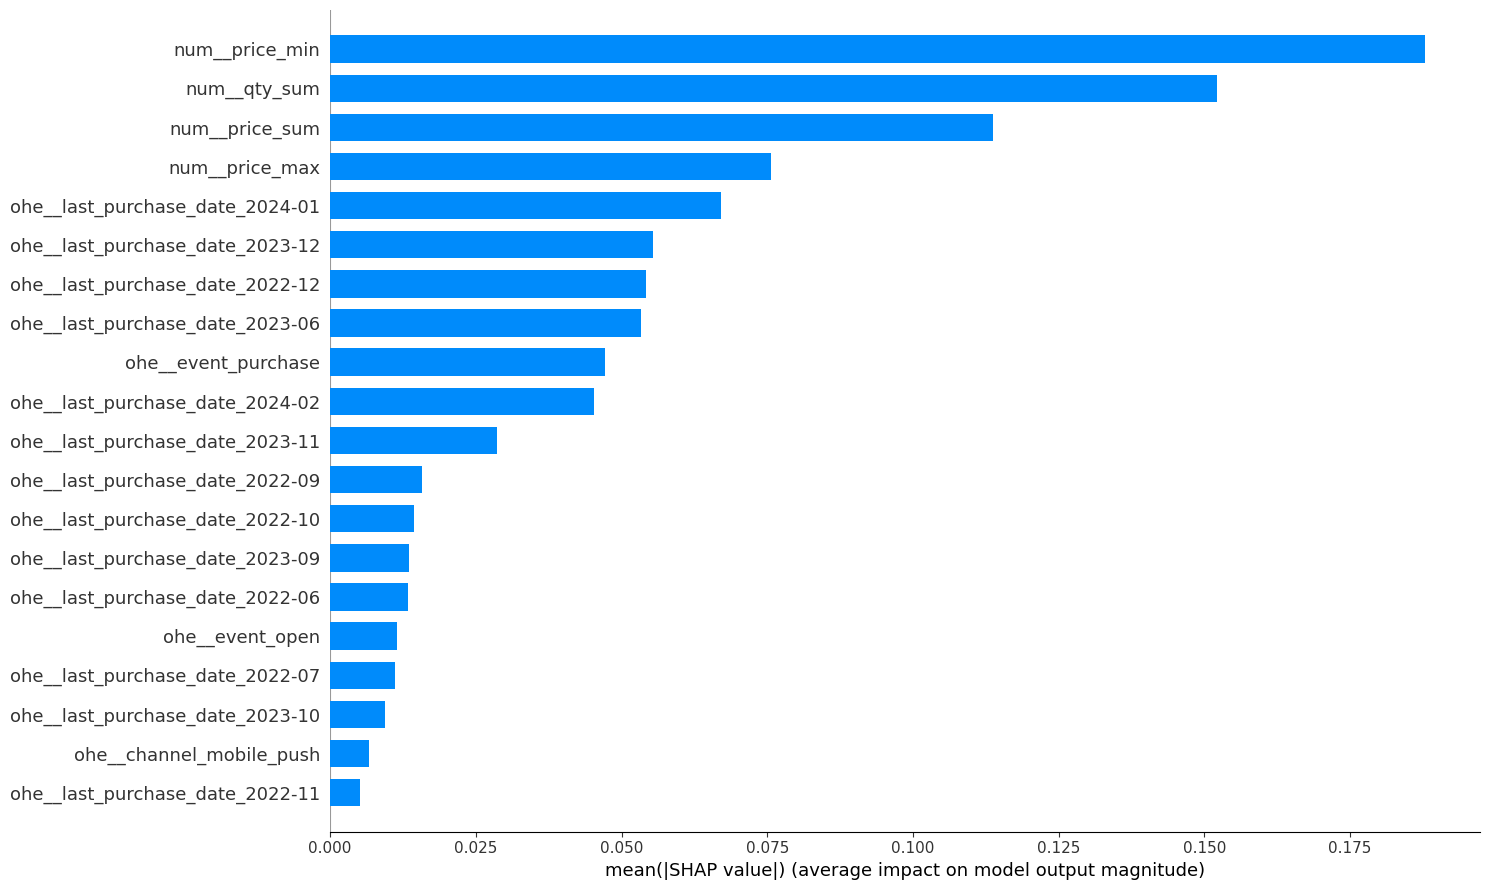

In [583]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_pr)
# рассчитываем значения Шепли
shap.summary_plot(shap_values, feature_names=feature_names, plot_size = (15,9), plot_type="bar")
# строим диаграмму вклада признаков в предсказание модели

Анализ важности показывает, что наибольшее влияние на работу модели оказывают признаки, связанные с суммой и количеством заказов:
- Минимальная и максимальная сумма заказа покупателя;
- Количество покупок;
- Сумма всех заказов покупателя.
Также достаточное влияние оказывает и признак последнего месяца и года заказа.

## Итоговые выводы.

В рамках данной работы мы провели анализ датасетов с данными о покупателях интернет-магазина с целью создания модели, предсказывающий, совершит ли покупатель покупки в ближайшие 90 дней.

На **первом этапе** исследования мы провели предварительный анализ исходных датасетов: данные о покупках (purchases_data), данные о рекламных рассылках (messages_data) и данные с целевым признаком для предсказания (target_data). \
В датасете purchases_data 202 208 строк с данными. Пропусков нет, все признаки имеют верный тип кроме date. Он имеет формат строки, хотя содержит дату. \
В датасете messages_data 12 739 798 строк с данными. Все признаки имеют верный тип кроме date и created_at. Они имеют формат строки, хотя содержат дату. \
В датасете target_data 49 849 строк с данными. Пропусков нет, все признаки имеют верный тип.

На **втором этапе** исследования мы провели предобработку данных: мы изменили столбцы с некорректным типом данных (date и created_at). Мы привели их к формату даты. Затем мы сделали дополнительную проверку пропусков и подтвердили их отсутствие в данных. На последнем шаге этапа мы проверили данные на дубликаты. Было выявлено:
- Явных дубликатов в датасете purchases_data: 73020
- Явных дубликатов в датасете messages_data: 48610
- Явных дубликатов в датасете target_data: 5
Мы удалили дубли в данных. Неявных дубликатов не выявлено.

На **третьем этапе** мы объединили три датасета в итоговый датасет для обучения final_data. \
Для этого мы сначала объединили датасеты purchases_data и messages_data. Чтобы не потерять важные признаки, мы создали новые, который агрегируют данные по рассылкам: общее количество отправок mes_qty. Затем мы удалили строки с дублирубщими id рассылок, оставив в date_mes запись с самой последней датой рассылки. После этого мы смогли объединить датасеты по полю message_id. Получившийся датасет мы назвали purchases_mes. \
Далее мы обработали датасет purchases_mes - создали новые агрегирующие признаки: общее и среднее количество покупок, общую и среднюю сумму заказа, максимальный и минимальный заказ, количество категорий товаров. Затем мы убрали дубли по покупателю, оставив в данных только данные по последней покупке. \
После этого мы смогли объединить датасеты purchases_mes и target_data. В получившемся датасета final_data мы обнаружили 260 пропусков - по целевому признаку нет данных о покупках и рассылках. Пропуски составили всего 0.52%, поэтому мы удалили эти строки из датасета для модели. Также мы преобразовали признаки с датами последней покупки и последней рассылки в более крупные: с месяцем и годом, а также отдельно добавили признак год покупки и год рассылки. \
На финальном шаге этапа мы проверили получившийся датасет на пропуски и дубли.

На **четвертом этапе** мы провели исследовательский анализ признаков. Сначала мы проанализировали количественные признаки датасета. \
Анализ признака target показывает, что в данных большой дисбаланс классов. У нас очень маленькое количество покупателей, совершивших покупки в течение 90 дней, по сравнению с не совершившими. Но каких-либо аномалий или выбросов нет. \
Признак mes_qty содержит в себе выбросы. Почти все клиенты получили не больше 2 рассылок, но есть 5 покупателей, которые совершили покупки после аномального количества сообщений - 322. Данные нельзя назвать ошибкой, вероятно, покупатели решить приобрести товары через большое количество времени и после множества рассылок. Решили не убирать эти данные из модели. \
В данных по price_sum обнаружено несколько выбросов, но было решено удалить только один с аномально высокой суммой почти 300 тыс. В данных по price_avg также обнаружено несколько аномально высокий значений, но нельзя считать, что это некорректные данные. Оставили их без изменений.
В признаке category_ids_qty мы видим, что большая часть клиентов покупала товары из 4 категорий, аномалий и выбросов нет. В признаке qty_sum, как и в сумме, мы видим несколько выбросов, но сильно выделяется один - с количеством 161 шт. Для лучшей работы модели убрали и его из данных. В признаке qty_avg есть также несколько выбросов, которые также нельзя считать аномалиями. \
В признаках с годом последней покупки (purch_year) и годом последней рассылки (mes_year) нет каких-либо выбросов. Мы видим, что в данных представлена информация о покупателях за 3 года - 2022, 2023 и 2024. Больше всего покупок и рассылок по пользователям датасета было в 2023 году.

Анализ категориальных признаков позволяет сделать следующие выводы:
- Больше всего покупок клиенты делали в июне 2023 (10.54% клиентов) и в июне 2022 (9.27% клиентов). Что говорит о том, что летом покупательская активность становится выше (данных за 2024 год просто слишком мало, чтобы попасть в топ).
- Из событий event мы видим, что 43.32% клиентов совершили покупку после рассылки, 21.20% отправили рассылку, 20.99% совершили переход по клику, а 14.42% просто открыли сообщение. И очень маленький процент покупателей отписались или пожаловались на рассылку, что может говорить об общей эффективности механизма рассылок.
- Основной канал распространения - email. 68.89% рассылок прошло через электронную почту, и только 31.11% прошло через мобильные пуш-уведомления.
- Объемы последних рассылок соответствуют данным о покупках. Больше всего рассылок в июне 2023 (10.42%) и 2022 (9.17%) годов. Есть явная зависимость между временем рассылки и временем покупки.

Далее мы провели корреляционный анализ признаков финального датасета. \
Мы обнаружили мультиколлинеарность между признаками mes_year, purch_year, last_purchase_date и last_date_mes и решили оставить в данных для модели только last_purchase_date. \
Линейные зависимости входных признаков с целевым target достаточно малы, а по ряду признаков сотавляет 0.00. Такие признаки не принесут пользы для работы моделей. Это признаки: qty_avg, category_ids_qty, price_avg и mes_qty. На финальном шаге этапа мы удалили эти ненужные признаки из датасета.

На **пятом этапе** мы разбили датасет для обучения на тренировочную и тестовую выборки, а также подготовили пайплайны для обработки пропусков, для кодирования и масштабирования признаков. Для кодирования категориальных признаков выбран OneHotEncoder, а для масштабирования - StandardScaler и MinMaxScaler.

На **шестом этапе** мы обучили несколько моделей и методом кросс-валидации выбрали лучшие. Мы использовали для обучения следующие модели:
- RandomForestClassifier;
- LGBMClassifier;
- LogisticRegression.

Для каждой модели в пайплайне мы задали набор гиперпараметров. В качестве метрики оценки качества модели была выбрана ROC_AUC. Затем при помощи метода RandomizedSearchCV мы выбрали лучшую модель для решения поставленной задачи. Ею оказалась модель с параметрами:
**LGBMClassifier(learning_rate=0.05, max_depth=3, n_estimators=200, num_leaves=20, objective='binary', random_state=42, verbose=-1))**. \
Метрика по кросс-валидации на тренировочных данных составила **0.6596**. Предсказания на тестовой выборке показали метрику в размере **0.6312**. Не самый лучший результат. \
Анализ важности признаков показывает, что наибольшее влияние на работу модели оказывают признаки, связанные с суммой и количеством заказов:
- Минимальная и максимальная сумма заказа покупателя;
- Количество покупок;
- Сумма всех заказов покупателя.

Также достаточное влияние оказывает и признак последнего месяца и года заказа.